# Assignment 3 : Auditable Biomedical Image-Analysis Pipeline
##**Name :** Owen Nda Diche | **Student ID:** 24152506

### **GitHub Repository:**

**Safety: Educational research only; this is not a medical device.**



# Project Summary:


This notebook develops and evaluates a compact pipeline for analysing synthetic fluorescence microscopy images of cell nuclei. It brings together three approaches: direct description with a local vision-language model, classical threshold based image analysis, and learned segmentation with a compact U-Net.

Four assessed tasks are presented in order so that each stage can be followed from raw image preparation to the final test set records.
The central design principle is **measurement before narration**.

Images and masks are processed deterministically, quantitative features are stored in structured records, and language model narratives are produced only as an explanatory layer. They are never fed back into the numerical analysis. This makes the workflow easier
to inspect, reproduce, and audit while acknowledging that the outputs are for educational research rather than clinical use.


## Quick start

This notebook is designed to run from top to bottom in a fresh Google Colab
session. Select **Runtime → Change runtime type → T4 GPU**, leave FULL_RUN set to
True for the assessed analysis, and then select **Runtime → Run all**. The first run
installs the required environment, downloads the dataset, and retrieves the local
Ollama models, so it will take longer than later cells and the browser tab should
remain open.

The configuration also supports a short smoke test, but its results are not a
substitute for the full assessed run. Every figure, table, prompt, raw model reply,
validated JSON record, trained checkpoint, and validation error is written to
/content/outputs. The final cell checks that the core evidence exists and packages
the directory as final_outputs.zip for download.


## 0. Configuration

The following cell gathers the main experimental choices in one place. These
include the random seed, training budget, U-Net capacity, loss functions, local
language models, and output locations. Keeping these parameters together makes the
full analysis reproducible and makes deliberate changes easy to identify. FULL_RUN
controls whether the complete comparison is performed or a reduced smoke test is
used to confirm that the workflow executes.


In [1]:
from pathlib import Path

FULL_RUN = True
SEED = 42
EPOCHS = 10 if FULL_RUN else 1
LOSS_NAMES = ["bce", "dice", "combined"] if FULL_RUN else ["combined"]
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
BASE_CHANNELS = 16 if FULL_RUN else 8
DEVICE = "auto"

RUN_LLM_STAGES = True
RUN_ROBUSTNESS_EXTENSION = FULL_RUN
VISION_MODEL = "llama3.2-vision"
TEXT_MODEL = "llama3.2"
OLLAMA_VERSION = "0.17.1"
VLM_REPEATS = 3

ROOT_DIR = Path("/content")
DATA_DIR = ROOT_DIR / "nuclei_dataset"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_URL = (
    "https://raw.githubusercontent.com/"
    "Nickolay-K/Assingnment-3-dataset/main/nuclei_dataset.zip"
)

print({
    "mode": "full" if FULL_RUN else "smoke test",
    "seed": SEED,
    "epochs": EPOCHS,
    "losses": LOSS_NAMES,
    "output_directory": str(OUTPUT_DIR),
})


{'mode': 'full', 'seed': 42, 'epochs': 10, 'losses': ['bce', 'dice', 'combined'], 'output_directory': '/content/outputs'}


## 1. Environment, local Ollama server, and dataset
This cell installs the required libraries, downloads, validates the dataset, and starts Ollama within the Colab session. Ollama 0.17.1 is used to support the llama3.2-vision model.

Because Colab storage is temporary, the dataset and models may need to be downloaded again in a new session. GPU information is also displayed to record the execution environment.


In [2]:
import os
import shutil
import subprocess
import sys
import time
import urllib.request
import zipfile

packages = [
    "numpy>=1.26,<3", "pandas>=2.2,<3", "Pillow>=10,<13",
    "matplotlib>=3.8,<4", "scikit-image>=0.23,<1",
    "torch>=2.2,<3", "requests>=2.31,<3",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)
import requests

def ollama_ready() -> bool:
    try:
        return requests.get("http://127.0.0.1:11434/api/tags", timeout=2).ok
    except requests.RequestException:
        return False

def ensure_ollama(version: str) -> None:
    current = ""
    if shutil.which("ollama"):
        check = subprocess.run(
            ["ollama", "--version"], capture_output=True, text=True, check=False
        )
        current = check.stdout + check.stderr
    if version not in current:
        if not shutil.which("zstd"):
            subprocess.run(["apt-get", "update", "-qq"], check=True)
            subprocess.run(
                ["apt-get", "install", "-y", "-qq", "zstd"], check=True
            )
        archive = Path(f"/tmp/ollama-linux-amd64-{version}.tar.zst")
        release_url = (
            "https://github.com/ollama/ollama/releases/download/"
            f"v{version}/ollama-linux-amd64.tar.zst"
        )
        print(f"Downloading Ollama {version} from its official release archive.")
        urllib.request.urlretrieve(release_url, archive)
        subprocess.run(
            ["tar", "--zstd", "-xf", str(archive), "-C", "/usr"],
            check=True,
        )

    os.environ["OLLAMA_HOST"] = "127.0.0.1:11434"
    if not ollama_ready():
        log = open("/content/ollama_serve.log", "w", encoding="utf-8")
        subprocess.Popen(
            ["ollama", "serve"], stdout=log, stderr=log, start_new_session=True
        )
        for _ in range(45):
            if ollama_ready():
                break
            time.sleep(1)
    if not ollama_ready():
        raise RuntimeError("Ollama did not start; inspect /content/ollama_serve.log")
    version_text = subprocess.run(
        ["ollama", "--version"], capture_output=True, text=True, check=True
    ).stdout.strip()
    print(version_text)

def ensure_dataset() -> None:
    expected = DATA_DIR / "train" / "images"
    if expected.exists():
        print(f"Dataset already present: {DATA_DIR}")
        return
    archive = ROOT_DIR / "nuclei_dataset.zip"
    urllib.request.urlretrieve(DATASET_URL, archive)
    with zipfile.ZipFile(archive) as bundle:
        bundle.extractall(ROOT_DIR)
    if not expected.exists():
        raise FileNotFoundError(f"Missing expected dataset path: {expected}")
    print(f"Dataset extracted: {DATA_DIR}")

ensure_dataset()
if RUN_LLM_STAGES:
    ensure_ollama(OLLAMA_VERSION)
    installed = subprocess.run(
        ["ollama", "list"], capture_output=True, text=True, check=True
    ).stdout
    for model_name in (VISION_MODEL, TEXT_MODEL):
        if model_name not in installed:
            print(f"Downloading {model_name}; this can take several minutes.")
            subprocess.run(["ollama", "pull", model_name], check=True)

if shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)


Dataset extracted: /content/nuclei_dataset
ollama version is 0.17.1


## 2. Reusable implementation
The implementation is divided into six sections covering data preparation, classical analysis, LLM interaction, U-Net training, figure generation, and workflow execution. This structure reduces duplication and separates measured results from generated descriptions.

Images are converted to grayscale and resized appropriately, while masks use nearest neighbour resizing to preserve labels. LLM outputs are validated against defined schemas, and only validation data is used for U-Net model selection and threshold calibration.


### 2.1 Data preparation and pairing checks

This section discovers the dataset files, confirms that every image has the
corresponding mask, and creates deterministic train, validation, and test records.
It also standardises the inputs to 256 × 256 pixels and produces the manifest used
throughout the remaining tasks. Performing these checks at the start prevents a
silent filename mismatch from invalidating later measurements or model evaluation.


In [4]:
"""Dataset preparation and PyTorch dataset helpers.

All image inputs are converted to one channel grayscale and resized to 256 x 256.
Masks use nearest-neighbour interpolation so their binary labels are not blurred.
"""

from __future__ import annotations

import random
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from PIL import Image


IMAGE_SIZE = (256, 256)
VALID_SPLITS = ("train", "val", "test")


@dataclass(frozen=True)
class ImagePair:
    """One image and its matching binary mask."""

    image_id: str
    image_path: Path
    mask_path: Path


def find_pairs(data_dir: Path, split: str) -> list[ImagePair]:
    """Return deterministically ordered image/mask pairs for a dataset split."""
    if split not in VALID_SPLITS:
        raise ValueError(f"split must be one of {VALID_SPLITS}; got {split!r}")

    image_dir = data_dir / split / "images"
    mask_dir = data_dir / split / "masks"
    if not image_dir.is_dir() or not mask_dir.is_dir():
        raise FileNotFoundError(
            f"Expected {image_dir} and {mask_dir}. Check --data-dir."
        )

    pairs: list[ImagePair] = []
    for image_path in sorted(image_dir.glob("*.png")):
        mask_path = mask_dir / image_path.name
        if not mask_path.exists():
            raise FileNotFoundError(f"No mask found for {image_path.name}: {mask_path}")
        pairs.append(ImagePair(image_path.stem, image_path, mask_path))
    if not pairs:
        raise FileNotFoundError(f"No PNG images found in {image_dir}")
    return pairs


def load_grayscale(path: Path, size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Load an image as a float32 grayscale array in [0, 1]."""
    with Image.open(path) as image:
        gray = image.convert("L").resize(size, Image.Resampling.BILINEAR)
        return np.asarray(gray, dtype=np.float32) / 255.0


def load_mask(path: Path, size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Load and resize a mask as a boolean array."""
    with Image.open(path) as image:
        mask = image.convert("L").resize(size, Image.Resampling.NEAREST)
        return np.asarray(mask, dtype=np.uint8) > 0


def load_instance_labels(path: Path, size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Load integer instance labels without collapsing their identifiers."""
    with Image.open(path) as image:
        labels = image.resize(size, Image.Resampling.NEAREST)
        return np.asarray(labels, dtype=np.int32)


def save_grayscale(array: np.ndarray, path: Path) -> None:
    """Save a normalized grayscale array to PNG."""
    path.parent.mkdir(parents=True, exist_ok=True)
    clipped = np.clip(array, 0.0, 1.0)
    Image.fromarray(np.round(clipped * 255).astype(np.uint8), mode="L").save(path)


def save_mask(mask: np.ndarray, path: Path) -> None:
    """Save a binary mask with conventional 0/255 encoding."""
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray((np.asarray(mask, dtype=bool) * 255).astype(np.uint8), mode="L").save(path)


def preprocess_dataset(data_dir: Path, output_dir: Path) -> pd.DataFrame:
    """Convert every split to 256 x 256 grayscale images and binary masks.

    Returns a manifest that makes the transformation auditable.
    """
    records: list[dict[str, object]] = []
    for split in VALID_SPLITS:
        for pair in find_pairs(data_dir, split):
            image = load_grayscale(pair.image_path)
            mask = load_mask(pair.mask_path)
            out_image = output_dir / split / "images" / pair.image_path.name
            out_mask = output_dir / split / "masks" / pair.mask_path.name
            save_grayscale(image, out_image)
            save_mask(mask, out_mask)
            records.append(
                {
                    "image_id": pair.image_id,
                    "split": split,
                    "source_image": str(pair.image_path.resolve()),
                    "processed_image": str(out_image.resolve()),
                    "width": image.shape[1],
                    "height": image.shape[0],
                    "min_intensity": float(image.min()),
                    "max_intensity": float(image.max()),
                    "mean_intensity": float(image.mean()),
                    "foreground_fraction": float(mask.mean()),
                }
            )
    manifest = pd.DataFrame.from_records(records)
    output_dir.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(output_dir / "preprocessing_manifest.csv", index=False)
    return manifest


def representative_image_id(data_dir: Path, manifest: pd.DataFrame) -> str:
    """Choose the train image whose object count is nearest the train median.

    This avoids cherry-picking an unusually easy or unusually dense field of view.
    """
    metadata_path = data_dir / "metadata.csv"
    if metadata_path.exists():
        metadata = pd.read_csv(metadata_path)
        train = metadata.loc[metadata["split"].eq("train")].copy()
        median_count = train["n_objects"].median()
        train["distance"] = (train["n_objects"] - median_count).abs()
        return str(train.sort_values(["distance", "image_id"]).iloc[0]["image_id"])

    train_manifest = manifest.loc[manifest["split"].eq("train")].copy()
    median_intensity = train_manifest["mean_intensity"].median()
    train_manifest["distance"] = (
        train_manifest["mean_intensity"] - median_intensity
    ).abs()
    return str(train_manifest.sort_values(["distance", "image_id"]).iloc[0]["image_id"])


def seed_everything(seed: int) -> None:
    """Seed Python, NumPy and (when installed) PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass


def iter_images(paths: Iterable[Path]) -> Iterable[tuple[Path, np.ndarray]]:
    """Yield path/array pairs; useful for EDA without retaining all arrays."""
    for path in paths:
        yield path, load_grayscale(path)


class NucleiDataset:
    """PyTorch-compatible dataset with paired geometric augmentation.

    PyTorch is imported lazily, which allows preparation/EDA to run before the
    optional training dependencies are installed.
    """

    def __init__(self, data_dir: Path, split: str, augment: bool = False):
        self.pairs = find_pairs(data_dir, split)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, index: int):
        import torch

        pair = self.pairs[index]
        image = load_grayscale(pair.image_path)
        mask = load_mask(pair.mask_path).astype(np.float32)

        if self.augment:
            if np.random.random() < 0.5:
                image, mask = np.fliplr(image), np.fliplr(mask)
            if np.random.random() < 0.5:
                image, mask = np.flipud(image), np.flipud(mask)
            k = int(np.random.randint(0, 4))
            image, mask = np.rot90(image, k), np.rot90(mask, k)

        image = np.ascontiguousarray(image, dtype=np.float32)
        mask = np.ascontiguousarray(mask, dtype=np.float32)
        return (
            torch.from_numpy(image).unsqueeze(0),
            torch.from_numpy(mask).unsqueeze(0),
            pair.image_id,
        )


### 2.2 Classical segmentation, region measurements, and quality gates

The classical branch applies Otsu thresholding followed by morphological cleanup,
connected component labelling, and region level measurement. Object count, area,
shape, solidity, and intensity statistics are converted into deterministic summary
categories before any text model is called. Quality gates record situations in
which a sparse, dense, or potentially unreliable mask should be interpreted with
caution.


In [5]:
"""Classical segmentation, deterministic measurements, and quality gates."""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from skimage import filters, measure, morphology



REGION_PROPERTIES = (
    "label",
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "major_axis_length",
    "minor_axis_length",
    "mean_intensity",
)


@dataclass
class ClassicalResult:
    """All deterministic outputs produced by the classical stage."""

    threshold: float
    raw_mask: np.ndarray
    clean_mask: np.ndarray
    labels: np.ndarray
    features: pd.DataFrame


def clean_binary_mask(
    mask: np.ndarray,
    min_area: int = 20,
    open_radius: int = 1,
    close_radius: int = 1,
) -> np.ndarray:
    """Remove specks/holes and lightly regularise object boundaries."""
    # scikit-image 0.26 renamed the size parameters. Supporting both APIs keeps
    # the submission runnable in the lab image and in current environments.
    try:
        cleaned = morphology.remove_small_objects(mask.astype(bool), max_size=min_area - 1)
        cleaned = morphology.remove_small_holes(cleaned, max_size=min_area - 1)
    except TypeError:
        cleaned = morphology.remove_small_objects(mask.astype(bool), min_size=min_area)
        cleaned = morphology.remove_small_holes(cleaned, area_threshold=min_area)
    if open_radius > 0:
        cleaned = morphology.opening(cleaned, morphology.disk(open_radius))
    if close_radius > 0:
        cleaned = morphology.closing(cleaned, morphology.disk(close_radius))
    return cleaned


def extract_region_features(image: np.ndarray, mask: np.ndarray) -> pd.DataFrame:
    """Measure connected foreground regions, including derived circularity."""
    labels = measure.label(mask.astype(bool), connectivity=2)
    if labels.max() == 0:
        return pd.DataFrame(columns=(*REGION_PROPERTIES, "circularity"))

    table = measure.regionprops_table(
        labels,
        intensity_image=np.asarray(image, dtype=np.float32),
        properties=REGION_PROPERTIES,
    )
    features = pd.DataFrame(table)
    perimeter_sq = features["perimeter"].pow(2)
    features["circularity"] = np.where(
        perimeter_sq > 0,
        4.0 * np.pi * features["area"] / perimeter_sq,
        np.nan,
    )
    return features.round(6)


def otsu_segment(
    image: np.ndarray,
    sigma: float = 1.0,
    min_area: int = 20,
    open_radius: int = 1,
    close_radius: int = 1,
) -> ClassicalResult:
    """Segment bright fluorescence nuclei with Otsu plus morphology."""
    image = np.asarray(image, dtype=np.float32)
    smoothed = filters.gaussian(image, sigma=sigma, preserve_range=True)
    threshold = float(filters.threshold_otsu(smoothed)) if np.ptp(smoothed) else float(smoothed.flat[0])
    raw_mask = smoothed > threshold
    clean_mask = clean_binary_mask(raw_mask, min_area, open_radius, close_radius)
    labels = measure.label(clean_mask, connectivity=2)
    features = extract_region_features(image, clean_mask)
    return ClassicalResult(threshold, raw_mask, clean_mask, labels, features)


def density_class(foreground_fraction: float) -> str:
    """Map mask coverage to a documented three-level density vocabulary."""
    if foreground_fraction < 0.05:
        return "sparse"
    if foreground_fraction < 0.12:
        return "moderate"
    return "dense"


def shape_regularity(features: pd.DataFrame) -> str:
    """Deterministic shape category used to audit the LLM response."""
    if features.empty:
        return "uncertain"
    median_solidity = float(features["solidity"].median())
    median_eccentricity = float(features["eccentricity"].median())
    if median_solidity >= 0.93 and median_eccentricity <= 0.72:
        return "regular"
    if median_solidity < 0.85 or median_eccentricity > 0.86:
        return "irregular"
    return "mixed"


def image_quality_metrics(image: np.ndarray) -> dict[str, float]:
    """Compute simple pre-segmentation contrast and focus indicators."""
    image = np.asarray(image, dtype=np.float32)
    p01, p99 = np.percentile(image, [1, 99])
    laplacian = filters.laplace(image)
    return {
        "intensity_mean": float(image.mean()),
        "intensity_std": float(image.std()),
        "contrast_p99_p01": float(p99 - p01),
        "focus_laplacian_variance": float(np.var(laplacian)),
    }


def quality_flag(image: np.ndarray, features: pd.DataFrame) -> str:
    """Flag weak inputs before prose generation.

    Thresholds are deliberately conservative for normalized fluorescence images.
    They are reported in the numerical summary so the decision is auditable.
    """
    quality = image_quality_metrics(image)
    if quality["contrast_p99_p01"] < 0.08 or quality["focus_laplacian_variance"] < 1e-5:
        return "fail"
    if quality["contrast_p99_p01"] < 0.18 or quality["focus_laplacian_variance"] < 5e-5:
        return "review_recommended"
    if features.empty:
        return "review_recommended"
    return "ok"


def summarise_features(image_id: str, image: np.ndarray, features: pd.DataFrame) -> dict[str, object]:
    """Build a compact numbers-only source record for a text-only LLM.

    The returned mapping contains measured values and fixed categories only. It
    intentionally contains no anatomical or diagnostic interpretation.
    """
    foreground_area = float(features["area"].sum()) if not features.empty else 0.0
    foreground_fraction = foreground_area / float(image.size)
    quality = image_quality_metrics(image)
    summary: dict[str, object] = {
        "image_id": image_id,
        "image_width_px": int(image.shape[1]),
        "image_height_px": int(image.shape[0]),
        "n_objects": int(len(features)),
        "foreground_fraction": round(foreground_fraction, 6),
        "density_class_calculated": density_class(foreground_fraction),
        "shape_regularity_calculated": shape_regularity(features),
        "quality_flag_calculated": quality_flag(image, features),
        **{key: round(value, 6) for key, value in quality.items()},
    }
    for column in ("area", "eccentricity", "solidity", "circularity", "mean_intensity"):
        values = features[column] if column in features else pd.Series(dtype=float)
        summary[f"{column}_mean"] = round(float(values.mean()), 6) if len(values) else None
        summary[f"{column}_median"] = round(float(values.median()), 6) if len(values) else None
        summary[f"{column}_std"] = round(float(values.std(ddof=0)), 6) if len(values) else None
    return summary


def binary_metrics(prediction: np.ndarray, target: np.ndarray, eps: float = 1e-7) -> dict[str, float]:
    """Return per-image Dice and IoU for two binary masks."""
    prediction = np.asarray(prediction, dtype=bool)
    target = np.asarray(target, dtype=bool)
    intersection = float(np.logical_and(prediction, target).sum())
    pred_area = float(prediction.sum())
    target_area = float(target.sum())
    union = float(np.logical_or(prediction, target).sum())
    return {
        "dice": (2.0 * intersection + eps) / (pred_area + target_area + eps),
        "iou": (intersection + eps) / (union + eps),
    }


def evaluate_otsu_split(data_dir: Path, split: str = "val") -> pd.DataFrame:
    """Evaluate the deterministic Otsu baseline against ground-truth masks."""
    records: list[dict[str, object]] = []
    for pair in find_pairs(data_dir, split):
        image = load_grayscale(pair.image_path)
        target = load_mask(pair.mask_path)
        result = otsu_segment(image)
        metrics = binary_metrics(result.clean_mask, target)
        records.append(
            {
                "image_id": pair.image_id,
                "method": "Otsu+morphology",
                "dice": metrics["dice"],
                "iou": metrics["iou"],
                "n_objects": len(result.features),
                "threshold": result.threshold,
            }
        )
    return pd.DataFrame.from_records(records)


def save_feature_table(features: pd.DataFrame, path: Path) -> None:
    """Persist measurements without a DataFrame index column."""
    path.parent.mkdir(parents=True, exist_ok=True)
    features.to_csv(path, index=False)


### 2.3 Local LLM prompts, schemas, retries, and audit validation

This section defines the prompts and structured output contracts used by both local
language models. The direct vision prompt is descriptive rather than diagnostic and
explicitly allows uncertainty. The numbers first and hybrid prompts receive only
calculated measurements, not the source image. Raw replies, parsing attempts, and
accepted records are retained so that a generated narrative can be traced back to
its prompt and checked against the numerical source of truth.


In [6]:
"""Local Ollama access, assignment prompts, JSON schemas, and validation.

The LLM is only a renderer/descriptor. Deterministic measurements are calculated
before the prompt, and returned numerical fields are checked against those values.
"""

from __future__ import annotations

import base64
import json
import urllib.error
import urllib.request
from pathlib import Path
from typing import Any


NAIVE_VISION_PROMPT = "What is this image?"


OPTIMISED_VISION_PROMPT = """You are describing one educational biomedical image for a research audit.
Describe only visible image content. This is not a diagnostic task.

Return ONLY one valid JSON object with exactly these fields:
- modality: a short imaging-modality phrase, or "uncertain"
- tissue_type: a short tissue/specimen phrase, or "uncertain"
- notable_features: a JSON list of zero to three short, directly visible features
- image_quality: exactly "good", "acceptable", "poor", or "uncertain"

Rules:
- Do not diagnose disease, infer patient attributes, or invent clinical history.
- Use "uncertain" whenever the image alone does not justify a claim.
- Keep notable_features descriptive (brightness, shapes, distribution, artefacts).
- No Markdown, explanation, or text outside the JSON object."""


TASK2_PROMPT = """You are a quantitative biomedical-image analyst.
The input below is a deterministic NUMERICAL SUMMARY. You cannot see the image.
Use only these supplied numbers and calculated categories; do not diagnose or add anatomy.

Return ONLY valid JSON matching the supplied schema. Requirements:
- Copy n_objects exactly from the summary.
- Copy density_class_calculated to density_class exactly.
- Copy shape_regularity_calculated to shape_regularity exactly.
- Copy quality_flag_calculated to quality_flag exactly.
- narrative must be one objective paragraph of 2-4 sentences grounded in the numbers.
- If evidence is missing, say "uncertain" rather than guessing.

NUMERICAL SUMMARY:
{summary}"""


HYBRID_PROMPT = """You are the final reporting stage of an auditable biomedical image pipeline.
The image has already been segmented and measured. You cannot see the image.
Use ONLY the numerical source record below. Do not diagnose, infer patient details, or add facts.

Return ONLY valid JSON matching the supplied schema. Requirements:
- Copy image_id, n_objects, mean_area, density_class_calculated, and
  quality_flag_calculated exactly into the corresponding record fields.
- narrative must be one objective paragraph of 2-4 sentences.
- Treat the structured record, not the prose, as the source of truth.
- If quality_flag is not "ok", explicitly say that review is recommended.

NUMERICAL SOURCE RECORD:
{summary}"""


DIRECT_VISION_SCHEMA: dict[str, Any] = {
    "type": "object",
    "properties": {
        "modality": {"type": "string"},
        "tissue_type": {"type": "string"},
        "notable_features": {
            "type": "array",
            "items": {"type": "string"},
            "maxItems": 3,
        },
        "image_quality": {
            "type": "string",
            "enum": ["good", "acceptable", "poor", "uncertain"],
        },
    },
    "required": ["modality", "tissue_type", "notable_features", "image_quality"],
    "additionalProperties": False,
}


TASK2_SCHEMA: dict[str, Any] = {
    "type": "object",
    "properties": {
        "record": {
            "type": "object",
            "properties": {
                "n_objects": {"type": "integer"},
                "density_class": {"type": "string", "enum": ["sparse", "moderate", "dense"]},
                "shape_regularity": {
                    "type": "string",
                    "enum": ["regular", "mixed", "irregular", "uncertain"],
                },
                "quality_flag": {
                    "type": "string",
                    "enum": ["ok", "review_recommended", "fail"],
                },
            },
            "required": ["n_objects", "density_class", "shape_regularity", "quality_flag"],
            "additionalProperties": False,
        },
        "narrative": {"type": "string"},
    },
    "required": ["record", "narrative"],
    "additionalProperties": False,
}


HYBRID_SCHEMA: dict[str, Any] = {
    "type": "object",
    "properties": {
        "record": {
            "type": "object",
            "properties": {
                "image_id": {"type": "string"},
                "n_objects": {"type": "integer"},
                "mean_area": {"type": "number"},
                "density_class": {"type": "string", "enum": ["sparse", "moderate", "dense"]},
                "quality_flag": {
                    "type": "string",
                    "enum": ["ok", "review_recommended", "fail"],
                },
            },
            "required": ["image_id", "n_objects", "mean_area", "density_class", "quality_flag"],
            "additionalProperties": False,
        },
        "narrative": {"type": "string"},
    },
    "required": ["record", "narrative"],
    "additionalProperties": False,
}


class OllamaError(RuntimeError):
    """Raised when the local Ollama server cannot satisfy a request."""


class OllamaClient:
    """Minimal standard-library client for Ollama's local chat API."""

    def __init__(self, base_url: str = "http://127.0.0.1:11434", timeout: int = 300):
        self.base_url = base_url.rstrip("/")
        self.timeout = timeout

    def available_models(self) -> list[str]:
        try:
            with urllib.request.urlopen(f"{self.base_url}/api/tags", timeout=10) as response:
                payload = json.load(response)
        except (OSError, urllib.error.URLError, json.JSONDecodeError) as exc:
            raise OllamaError(
                "Cannot reach Ollama. Start it with `ollama serve`, then pull the required models."
            ) from exc
        return [str(item.get("name", "")) for item in payload.get("models", [])]

    def chat(
        self,
        model: str,
        prompt: str,
        *,
        image_path: Path | None = None,
        temperature: float = 0.0,
        schema: dict[str, Any] | None = None,
        seed: int | None = 42,
    ) -> str:
        message: dict[str, Any] = {"role": "user", "content": prompt}
        if image_path is not None:
            message["images"] = [base64.b64encode(image_path.read_bytes()).decode("ascii")]
        options: dict[str, Any] = {"temperature": temperature}
        if seed is not None:
            options["seed"] = seed
        body: dict[str, Any] = {
            "model": model,
            "messages": [message],
            "stream": False,
            "options": options,
        }
        if schema is not None:
            body["format"] = schema
        request = urllib.request.Request(
            f"{self.base_url}/api/chat",
            data=json.dumps(body).encode("utf-8"),
            headers={"Content-Type": "application/json"},
            method="POST",
        )
        try:
            with urllib.request.urlopen(request, timeout=self.timeout) as response:
                payload = json.load(response)
        except urllib.error.HTTPError as exc:
            detail = exc.read().decode("utf-8", errors="replace")
            if "unknown model architecture" in detail and "mllama" in detail:
                detail += (
                    "\nThe installed Ollama runtime cannot load the mllama vision architecture. "
                    "This is a known Ollama runner regression (ollama/ollama issue #16490) "
                    "that is still reproducible on Windows 0.32.11. Re-pulling the model does "
                    "not repair it. Use a known-compatible Ollama runtime, run this stage on "
                    "another compatible machine, or explicitly select a different vision model "
                    "with --vision-model and disclose the substitution in the report."
                )
            raise OllamaError(f"Ollama HTTP {exc.code}: {detail}") from exc
        except (OSError, urllib.error.URLError, json.JSONDecodeError) as exc:
            raise OllamaError(f"Ollama request failed for model {model!r}: {exc}") from exc
        try:
            return str(payload["message"]["content"])
        except (KeyError, TypeError) as exc:
            raise OllamaError(f"Unexpected Ollama response: {payload}") from exc


def parse_json_object(text: str) -> dict[str, Any]:
    """Parse a model JSON response, tolerating code fences or brief preambles."""
    cleaned = text.strip()
    if cleaned.startswith("```"):
        lines = cleaned.splitlines()
        cleaned = "\n".join(lines[1:-1] if lines[-1].strip() == "```" else lines[1:])
    try:
        value = json.loads(cleaned)
    except json.JSONDecodeError:
        start, end = cleaned.find("{"), cleaned.rfind("}")
        if start < 0 or end <= start:
            raise
        value = json.loads(cleaned[start : end + 1])
    if not isinstance(value, dict):
        raise ValueError("Expected a JSON object at the response root")
    return value


def validate_direct_record(record: dict[str, Any]) -> list[str]:
    """Return validation errors for the Task 1 record."""
    errors: list[str] = []
    expected = set(DIRECT_VISION_SCHEMA["required"])
    if set(record) != expected:
        errors.append(f"fields must be exactly {sorted(expected)}")
    for field in ("modality", "tissue_type", "image_quality"):
        if not isinstance(record.get(field), str):
            errors.append(f"{field} must be a string")
    features = record.get("notable_features")
    if not isinstance(features, list) or len(features) > 3 or not all(isinstance(x, str) for x in features):
        errors.append("notable_features must be a list of at most three strings")
    if record.get("image_quality") not in {"good", "acceptable", "poor", "uncertain"}:
        errors.append("invalid image_quality vocabulary")
    return errors


def _validate_wrapper(wrapper: dict[str, Any]) -> tuple[dict[str, Any], str, list[str]]:
    record = wrapper.get("record")
    narrative = wrapper.get("narrative")
    errors: list[str] = []
    if not isinstance(record, dict):
        errors.append("record must be an object")
        record = {}
    if not isinstance(narrative, str) or not narrative.strip():
        errors.append("narrative must be a non-empty string")
        narrative = ""
    return record, narrative.strip(), errors


def validate_task2_wrapper(wrapper: dict[str, Any], summary: dict[str, Any]) -> list[str]:
    record, _, errors = _validate_wrapper(wrapper)
    expected = {
        "n_objects": summary["n_objects"],
        "density_class": summary["density_class_calculated"],
        "shape_regularity": summary["shape_regularity_calculated"],
        "quality_flag": summary["quality_flag_calculated"],
    }
    for key, value in expected.items():
        if record.get(key) != value:
            errors.append(f"record.{key}={record.get(key)!r}; expected {value!r}")
    return errors


def hybrid_source_record(summary: dict[str, Any]) -> dict[str, Any]:
    """Select the five fields required by Task 4 from measured values."""
    mean_area = summary.get("area_mean")
    return {
        "image_id": summary["image_id"],
        "n_objects": summary["n_objects"],
        "mean_area": 0.0 if mean_area is None else float(mean_area),
        "density_class": summary["density_class_calculated"],
        "quality_flag": summary["quality_flag_calculated"],
    }


def validate_hybrid_wrapper(wrapper: dict[str, Any], summary: dict[str, Any]) -> list[str]:
    record, _, errors = _validate_wrapper(wrapper)
    expected = hybrid_source_record(summary)
    for key, value in expected.items():
        returned = record.get(key)
        if key == "mean_area" and isinstance(returned, (int, float)):
            if abs(float(returned) - float(value)) > 1e-3:
                errors.append(f"record.mean_area={returned!r}; expected {value!r}")
        elif returned != value:
            errors.append(f"record.{key}={returned!r}; expected {value!r}")
    return errors


def query_json_with_validation(
    client: OllamaClient,
    model: str,
    prompt: str,
    schema: dict[str, Any],
    validator,
    *,
    temperature: float = 0.0,
    max_attempts: int = 2,
) -> tuple[dict[str, Any], str, list[str]]:
    """Query, parse, and retry once if the structured response is inconsistent."""
    errors: list[str] = []
    raw = ""
    for attempt in range(1, max_attempts + 1):
        repair = ""
        if errors:
            repair = "\n\nYour previous response failed validation: " + "; ".join(errors) + ". Correct it."
        raw = client.chat(
            model,
            prompt + repair,
            temperature=temperature,
            schema=schema,
            seed=42,
        )
        try:
            parsed = parse_json_object(raw)
            errors = list(validator(parsed))
        except (json.JSONDecodeError, ValueError) as exc:
            parsed = {}
            errors = [f"invalid JSON: {exc}"]
        if not errors:
            return parsed, raw, []
    return parsed, raw, errors


def save_prompts(path: Path) -> None:
    """Write every optimized prompt verbatim for inclusion in the report."""
    path.parent.mkdir(parents=True, exist_ok=True)
    content = (
        "TASK 1 - NAIVE VISION PROMPT\n"
        + NAIVE_VISION_PROMPT
        + "\n\nTASK 1 - OPTIMISED DESCRIPTIVE JSON PROMPT\n"
        + OPTIMISED_VISION_PROMPT
        + "\n\nTASK 2 - NUMBERS-FIRST PROMPT\n"
        + TASK2_PROMPT
        + "\n\nTASK 4 - HYBRID REPORTING PROMPT\n"
        + HYBRID_PROMPT
        + "\n"
    )
    path.write_text(content, encoding="utf-8")


### 2.4 Compact U-Net, losses, training, calibration, and evaluation

A compact U-Net is trained to predict a binary nuclei mask from each standardised
image. BCE, Dice, and combined BCE–Dice losses are compared under the same split,
seed, architecture, optimiser, and epoch budget, making the loss function the main
experimental variable. Validation Dice selects the checkpoint, and Dice and IoU
provide complementary measures of overlap between predicted and reference masks.


In [7]:
"""Compact U-Net, losses, training, evaluation, and prediction helpers."""

from __future__ import annotations

import json
import shutil
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader



class DoubleConv(nn.Module):
    """Two convolution/batch-normalisation/ReLU layers."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.block(inputs)


class UNet(nn.Module):
    """Three level U-Net sized for 256 x 256 single channel inputs."""

    def __init__(self, in_channels: int = 1, out_channels: int = 1, base: int = 16):
        super().__init__()
        self.base = base
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.bottleneck = DoubleConv(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.output = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        enc1 = self.enc1(inputs)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        bottleneck = self.bottleneck(self.pool(enc3))

        dec3 = self.dec3(torch.cat((self.up3(bottleneck), enc3), dim=1))
        dec2 = self.dec2(torch.cat((self.up2(dec3), enc2), dim=1))
        dec1 = self.dec1(torch.cat((self.up1(dec2), enc1), dim=1))
        return self.output(dec1)


def dice_loss(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    """Soft Dice loss averaged over images."""
    probabilities = torch.sigmoid(logits)
    intersection = (probabilities * target).sum(dim=(1, 2, 3))
    denominator = probabilities.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()


def bce_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return F.binary_cross_entropy_with_logits(logits, target)


def combined_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """Pixel-wise BCE plus overlap-aware Dice, as used in the segmentation lab."""
    return bce_loss(logits, target) + dice_loss(logits, target)


LOSS_FUNCTIONS: dict[str, Callable[[torch.Tensor, torch.Tensor], torch.Tensor]] = {
    "bce": bce_loss,
    "dice": dice_loss,
    "combined": combined_loss,
}


def resolve_device(requested: str = "auto") -> torch.device:
    """Choose CUDA/MPS when available, otherwise CPU."""
    if requested != "auto":
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def _scores_from_logits(
    logits: torch.Tensor, target: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7
) -> tuple[torch.Tensor, torch.Tensor]:
    prediction = torch.sigmoid(logits) >= threshold
    target_bool = target >= 0.5
    intersection = (prediction & target_bool).sum(dim=(1, 2, 3)).float()
    pred_area = prediction.sum(dim=(1, 2, 3)).float()
    target_area = target_bool.sum(dim=(1, 2, 3)).float()
    union = (prediction | target_bool).sum(dim=(1, 2, 3)).float()
    dice = (2.0 * intersection + eps) / (pred_area + target_area + eps)
    iou = (intersection + eps) / (union + eps)
    return dice, iou


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    loss_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] | None = None,
    threshold: float | None = None,
) -> tuple[dict[str, float], pd.DataFrame]:
    """Evaluate using per image scores before taking the arithmetic mean."""
    decision_threshold = float(
        getattr(model, "decision_threshold", 0.5) if threshold is None else threshold
    )
    was_training = model.training
    model.eval()
    records: list[dict[str, object]] = []
    weighted_loss = 0.0
    n_images = 0
    for images, masks, image_ids in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        if loss_fn is not None:
            weighted_loss += float(loss_fn(logits, masks).item()) * images.shape[0]
        n_images += images.shape[0]
        dice, iou = _scores_from_logits(logits, masks, threshold=decision_threshold)
        for index, image_id in enumerate(image_ids):
            records.append(
                {
                    "image_id": image_id,
                    "dice": float(dice[index].cpu()),
                    "iou": float(iou[index].cpu()),
                }
            )
    model.train(was_training)
    per_image = pd.DataFrame.from_records(records)
    metrics = {
        "loss": weighted_loss / n_images if loss_fn is not None else float("nan"),
        "mean_dice": float(per_image["dice"].mean()),
        "mean_iou": float(per_image["iou"].mean()),
        "std_dice": float(per_image["dice"].std(ddof=0)),
        "std_iou": float(per_image["iou"].std(ddof=0)),
        "n_images": int(n_images),
        "threshold": decision_threshold,
    }
    return metrics, per_image


def calibrate_threshold(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    candidates: np.ndarray | None = None,
) -> tuple[float, pd.DataFrame]:
    """Choose one validation set probability threshold by mean Dice.

    A fixed 0.5 cutoff is not guaranteed to be calibrated for overlap losses.
    The selected value is saved in the checkpoint and then frozen for the test
    set. The search table makes this model-selection decision explicit.
    """
    if candidates is None:
        candidates = np.arange(0.10, 0.951, 0.05)
    rows: list[dict[str, float]] = []
    for threshold in candidates:
        metrics, _ = evaluate_model(model, loader, device, threshold=float(threshold))
        rows.append(
            {
                "threshold": float(threshold),
                "mean_dice": metrics["mean_dice"],
                "mean_iou": metrics["mean_iou"],
            }
        )
    frame = pd.DataFrame(rows)
    best = frame.sort_values(["mean_dice", "threshold"], ascending=[False, True]).iloc[0]
    return float(best["threshold"]), frame


def train_one_model(
    train_dataset: NucleiDataset,
    val_dataset: NucleiDataset,
    output_dir: Path,
    loss_name: str = "combined",
    epochs: int = 10,
    batch_size: int = 8,
    learning_rate: float = 1e-3,
    base: int = 16,
    seed: int = 42,
    device_name: str = "auto",
    num_workers: int = 0,
) -> tuple[UNet, pd.DataFrame, dict[str, float], pd.DataFrame, Path]:
    """Train a fresh U-Net and save its checkpoint/history/validation scores."""
    if loss_name not in LOSS_FUNCTIONS:
        raise ValueError(f"Unknown loss {loss_name!r}; choose from {tuple(LOSS_FUNCTIONS)}")
    if epochs < 1:
        raise ValueError("epochs must be at least 1")

    seed_everything(seed)
    device = resolve_device(device_name)
    loss_fn = LOSS_FUNCTIONS[loss_name]
    model = UNet(base=base).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=num_workers,
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    history: list[dict[str, float | int]] = []
    best_dice = -1.0
    best_state: dict[str, torch.Tensor] | None = None
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_total = 0.0
        for images, masks, _ in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(images), masks)
            loss.backward()
            optimizer.step()
            train_loss_total += float(loss.item()) * images.shape[0]

        val_metrics, _ = evaluate_model(model, val_loader, device, loss_fn)
        train_loss = train_loss_total / len(train_dataset)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_metrics["loss"],
                "val_dice": val_metrics["mean_dice"],
                "val_iou": val_metrics["mean_iou"],
            }
        )
        print(
            f"[{loss_name:8s}] epoch {epoch:02d}/{epochs}: "
            f"train={train_loss:.4f}, val={val_metrics['loss']:.4f}, "
            f"Dice={val_metrics['mean_dice']:.4f}, IoU={val_metrics['mean_iou']:.4f}"
        )
        if val_metrics["mean_dice"] > best_dice:
            best_dice = val_metrics["mean_dice"]
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    if best_state is None:
        raise RuntimeError("Training completed without producing a checkpoint")
    model.load_state_dict(best_state)
    calibrated_threshold, calibration = calibrate_threshold(model, val_loader, device)
    model.decision_threshold = calibrated_threshold
    final_metrics, per_image = evaluate_model(model, val_loader, device, loss_fn)

    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = output_dir / f"unet_{loss_name}.pt"
    torch.save(
        {
            "state_dict": model.state_dict(),
            "base": base,
            "loss_name": loss_name,
            "seed": seed,
            "image_size": [256, 256],
            "validation_metrics": final_metrics,
            "threshold": calibrated_threshold,
        },
        checkpoint_path,
    )
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(output_dir / f"history_{loss_name}.csv", index=False)
    per_image.assign(method=f"U-Net ({loss_name})").to_csv(
        output_dir / f"validation_per_image_{loss_name}.csv", index=False
    )
    calibration.to_csv(output_dir / f"threshold_calibration_{loss_name}.csv", index=False)
    with (output_dir / f"metrics_{loss_name}.json").open("w", encoding="utf-8") as handle:
        json.dump(final_metrics, handle, indent=2)
    return model, history_frame, final_metrics, per_image, checkpoint_path


def train_loss_ablation(
    data_dir: Path,
    output_dir: Path,
    loss_names: list[str],
    epochs: int,
    batch_size: int,
    learning_rate: float,
    base: int,
    seed: int,
    device_name: str,
) -> tuple[Path, pd.DataFrame, dict[str, pd.DataFrame]]:
    """Train identical U-Nets under one or more loss functions."""
    train_dataset = NucleiDataset(data_dir, "train", augment=True)
    val_dataset = NucleiDataset(data_dir, "val", augment=False)
    rows: list[dict[str, object]] = []
    histories: dict[str, pd.DataFrame] = {}
    checkpoints: dict[str, Path] = {}
    for loss_name in loss_names:
        _, history, metrics, _, checkpoint = train_one_model(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            output_dir=output_dir,
            loss_name=loss_name,
            epochs=epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            base=base,
            seed=seed,
            device_name=device_name,
        )
        histories[loss_name] = history
        checkpoints[loss_name] = checkpoint
        rows.append(
            {
                "method": f"U-Net ({loss_name})",
                "loss": loss_name,
                "mean_dice": metrics["mean_dice"],
                "mean_iou": metrics["mean_iou"],
                "std_dice": metrics["std_dice"],
                "std_iou": metrics["std_iou"],
                "epochs": epochs,
                "seed": seed,
                "threshold": metrics["threshold"],
            }
        )

    comparison = pd.DataFrame(rows).sort_values("mean_dice", ascending=False).reset_index(drop=True)
    best_loss = str(comparison.iloc[0]["loss"])
    best_checkpoint = output_dir / "best_model.pt"
    shutil.copyfile(checkpoints[best_loss], best_checkpoint)
    comparison.to_csv(output_dir / "unet_loss_comparison.csv", index=False)
    return best_checkpoint, comparison, histories


def load_model(checkpoint_path: Path, device_name: str = "auto") -> tuple[UNet, torch.device, dict]:
    """Reconstruct a U-Net from a saved checkpoint."""
    device = resolve_device(device_name)
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:  # compatibility with older PyTorch releases
        checkpoint = torch.load(checkpoint_path, map_location=device)
    model = UNet(base=int(checkpoint.get("base", 16))).to(device)
    model.load_state_dict(checkpoint["state_dict"])
    model.decision_threshold = float(checkpoint.get("threshold", 0.5))
    model.eval()
    return model, device, checkpoint


@torch.no_grad()
def predict_probability(model: nn.Module, image: np.ndarray, device: torch.device) -> np.ndarray:
    """Predict a probability map for one normalized 2-D image."""
    tensor = torch.from_numpy(np.asarray(image, dtype=np.float32))[None, None].to(device)
    return torch.sigmoid(model(tensor))[0, 0].cpu().numpy()


def predict_mask(
    model: nn.Module, image: np.ndarray, device: torch.device, threshold: float | None = None
) -> np.ndarray:
    """Threshold a U-Net probability map into a binary segmentation."""
    decision_threshold = float(
        getattr(model, "decision_threshold", 0.5) if threshold is None else threshold
    )
    return predict_probability(model, image, device) >= decision_threshold


### 2.5 Figures generated directly from pipeline outputs

All plots and image panels are generated from saved pipeline results rather than
manually transcribed values. This includes the exploratory overview, training
curves, validation predictions, and Otsu-versus-U-Net comparisons. Producing figures
programmatically keeps the notebook, exported evidence, and final report aligned.


In [8]:
"""Visualisations generated directly from pipeline outputs."""

from __future__ import annotations

import os
import tempfile
from pathlib import Path

# Matplotlib otherwise writes a font cache under the user's profile, which can
# fail in managed lab/assessment environments. A temporary cache is sufficient.
os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "biomed_pipeline_matplotlib")
)

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



def _style() -> None:
    plt.rcParams.update(
        {
            "figure.dpi": 140,
            "savefig.dpi": 220,
            "font.size": 9,
            "axes.titlesize": 10,
            "axes.labelsize": 9,
        }
    )


def plot_eda(data_dir: Path, output_path: Path, n_samples: int = 5) -> None:
    """Show representative grayscale inputs and a split-wide intensity histogram."""
    _style()
    pairs = find_pairs(data_dir, "train")
    indices = np.linspace(0, len(pairs) - 1, n_samples, dtype=int)
    selected = [pairs[index] for index in indices]
    histogram = np.zeros(256, dtype=np.int64)
    for pair in pairs:
        image = load_grayscale(pair.image_path)
        counts, _ = np.histogram(image, bins=256, range=(0, 1))
        histogram += counts

    fig, axes = plt.subplots(2, 3, figsize=(10, 6.2))
    for axis, pair in zip(axes.flat[:5], selected):
        axis.imshow(load_grayscale(pair.image_path), cmap="gray", vmin=0, vmax=1)
        axis.set_title(pair.image_id)
        axis.axis("off")
    histogram_axis = axes.flat[5]
    centers = (np.arange(256) + 0.5) / 256
    histogram_axis.plot(centers, histogram / histogram.sum(), color="#26547c", linewidth=1.5)
    histogram_axis.set_title("Train-set intensity distribution")
    histogram_axis.set_xlabel("Normalized grayscale intensity")
    histogram_axis.set_ylabel("Pixel proportion")
    histogram_axis.set_xlim(0, 1)
    fig.suptitle("Prepared fluorescence-microscopy data (256 × 256 grayscale)", fontsize=12)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_training_curves(histories: dict[str, pd.DataFrame], output_path: Path) -> None:
    """Plot validation/training loss and overlap for every loss ablation."""
    _style()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
    colors = {"bce": "#ef476f", "dice": "#118ab2", "combined": "#06d6a0"}
    for loss_name, history in histories.items():
        color = colors.get(loss_name)
        axes[0].plot(history["epoch"], history["train_loss"], "--", color=color, alpha=0.7)
        axes[0].plot(history["epoch"], history["val_loss"], label=f"{loss_name} val", color=color)
        axes[1].plot(history["epoch"], history["val_dice"], label=f"{loss_name} Dice", color=color)
        axes[1].plot(history["epoch"], history["val_iou"], "--", label=f"{loss_name} IoU", color=color)
    axes[0].set(title="Training and validation loss", xlabel="Epoch", ylabel="Loss")
    axes[1].set(title="Validation overlap", xlabel="Epoch", ylabel="Score", ylim=(0, 1.01))
    for axis in axes:
        axis.grid(alpha=0.2)
        axis.legend(fontsize=7)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_classical_segmentation(
    image: np.ndarray,
    raw_mask: np.ndarray,
    clean_mask: np.ndarray,
    labels: np.ndarray,
    output_path: Path,
) -> None:
    """Visualise the four deterministic stages of classical segmentation."""
    _style()
    fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))
    panels = (
        (image, "Grayscale input", "gray"),
        (raw_mask, "Otsu mask", "gray"),
        (clean_mask, "Morphological cleanup", "gray"),
        (labels, f"Connected components\n(n={int(labels.max())})", "nipy_spectral"),
    )
    for axis, (panel, title, colour_map) in zip(axes, panels):
        axis.imshow(panel, cmap=colour_map)
        axis.set_title(title)
        axis.axis("off")
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


def plot_validation_predictions(
    model,
    device,
    data_dir: Path,
    per_image: pd.DataFrame,
    output_path: Path,
) -> list[str]:
    """Plot three validation cases spanning low/median/high U-Net Dice."""
    _style()
    ordered = per_image.sort_values("dice").reset_index(drop=True)
    positions = sorted(set([0, len(ordered) // 2, len(ordered) - 1]))
    image_ids = [str(ordered.iloc[position]["image_id"]) for position in positions]
    lookup = {pair.image_id: pair for pair in find_pairs(data_dir, "val")}
    fig, axes = plt.subplots(len(image_ids), 3, figsize=(8.2, 2.7 * len(image_ids)))
    axes = np.atleast_2d(axes)
    for row, image_id in enumerate(image_ids):
        pair = lookup[image_id]
        image = load_grayscale(pair.image_path)
        target = load_mask(pair.mask_path)
        prediction = predict_mask(model, image, device)
        score = float(ordered.loc[ordered["image_id"].eq(image_id), "dice"].iloc[0])
        panels = ((image, "Input"), (target, "Ground truth"), (prediction, f"U-Net prediction\nDice={score:.3f}"))
        for column, (panel, title) in enumerate(panels):
            axes[row, column].imshow(panel, cmap="gray", vmin=0, vmax=1)
            axes[row, column].set_title(f"{image_id}: {title}" if column == 0 else title)
            axes[row, column].axis("off")
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)
    return image_ids


def plot_otsu_unet_examples(
    model,
    device,
    data_dir: Path,
    comparison: pd.DataFrame,
    output_path: Path,
) -> dict[str, str]:
    """Show U-Net's pixel-overlap win and Otsu's strongest object-count case."""
    _style()
    frame = comparison.copy()
    frame["unet_advantage"] = frame["unet_dice"] - frame["otsu_dice"]
    unet_id = str(frame.sort_values("unet_advantage", ascending=False).iloc[0]["image_id"])
    if "count_error_difference_unet_minus_otsu" in frame:
        # Positive means U-Net's object-count error was larger, so Otsu was better.
        otsu_id = str(
            frame.sort_values("count_error_difference_unet_minus_otsu", ascending=False)
            .iloc[0]["image_id"]
        )
    else:
        otsu_id = str(frame.sort_values("unet_advantage", ascending=True).iloc[0]["image_id"])
    ids = [unet_id, otsu_id]
    lookup = {pair.image_id: pair for pair in find_pairs(data_dir, "val")}
    fig, axes = plt.subplots(2, 4, figsize=(10.2, 5.4))
    for row, image_id in enumerate(ids):
        pair = lookup[image_id]
        image = load_grayscale(pair.image_path)
        target = load_mask(pair.mask_path)
        otsu_mask = otsu_segment(image).clean_mask
        unet_mask = predict_mask(model, image, device)
        values = frame.loc[frame["image_id"].eq(image_id)].iloc[0]
        count_text = ""
        if "gt_n_objects" in values:
            count_text = (
                f"\nObjects GT/O/U: {int(values['gt_n_objects'])}/"
                f"{int(values['otsu_n_objects'])}/{int(values['unet_n_objects'])}"
            )
        panels = (
            (image, f"{image_id}\nInput"),
            (target, "Ground truth"),
            (otsu_mask, f"Otsu\nDice={values['otsu_dice']:.3f}{count_text}"),
            (unet_mask, f"U-Net\nDice={values['unet_dice']:.3f}"),
        )
        for column, (panel, title) in enumerate(panels):
            axes[row, column].imshow(panel, cmap="gray", vmin=0, vmax=1)
            axes[row, column].set_title(title)
            axes[row, column].axis("off")
    fig.suptitle("Complementary validation cases: overlap and object-count error", fontsize=11)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)
    return {"unet_pixel_overlap_best": unet_id, "otsu_object_count_best": otsu_id}


def plot_robustness_trace(
    original: np.ndarray,
    corrupted: np.ndarray,
    original_mask: np.ndarray,
    corrupted_mask: np.ndarray,
    title: str,
    output_path: Path,
) -> None:
    """Trace one corruption through input and U-Net segmentation stages."""
    _style()
    fig, axes = plt.subplots(1, 4, figsize=(10, 2.7))
    panels = (
        (original, "Original input"),
        (corrupted, "Corrupted input"),
        (original_mask, "Original prediction"),
        (corrupted_mask, "Corrupted prediction"),
    )
    for axis, (panel, label) in zip(axes, panels):
        axis.imshow(panel, cmap="gray", vmin=0, vmax=1)
        axis.set_title(label)
        axis.axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    plt.close(fig)


### 2.6 End to end task orchestration and robustness trace

The workflow functions connect the reusable components into the four assessed tasks
and the additional robustness analysis. Each stage writes its intermediate and
final artifacts to a named task directory. This preserves a clear audit trail from
an input image through its mask and feature table to the validated JSON record and
explanatory narrative.


In [9]:
"""End to end orchestration and extension analyses."""

from __future__ import annotations

import json
import math
import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from torch.utils.data import DataLoader



def _write_json(path: Path, payload: Any) -> None:
    def make_safe(value: Any) -> Any:
        if isinstance(value, dict):
            return {str(key): make_safe(item) for key, item in value.items()}
        if isinstance(value, (list, tuple)):
            return [make_safe(item) for item in value]
        if isinstance(value, (np.integer,)):
            return int(value)
        if isinstance(value, (np.floating, float)):
            number = float(value)
            return number if math.isfinite(number) else None
        return value

    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(make_safe(payload), handle, indent=2, ensure_ascii=False, default=str, allow_nan=False)


def ensure_prepared(data_dir: Path, output_dir: Path) -> tuple[Path, pd.DataFrame]:
    """Return prepared dataset path, creating it when needed."""
    prepared_dir = output_dir / "preprocessed"
    manifest_path = prepared_dir / "preprocessing_manifest.csv"
    if manifest_path.exists():
        manifest = pd.read_csv(manifest_path)
    else:
        manifest = preprocess_dataset(data_dir, prepared_dir)
    return prepared_dir, manifest


def run_preparation(data_dir: Path, output_dir: Path) -> dict[str, object]:
    """Task 1 preprocessing, EDA, representative selection, and prompt export."""
    prepared_dir, manifest = ensure_prepared(data_dir, output_dir)
    plot_eda(prepared_dir, output_dir / "task1" / "eda_overview.png")
    selected = representative_image_id(data_dir, manifest)
    save_prompts(output_dir / "prompts.txt")
    result = {
        "n_images": int(len(manifest)),
        "split_counts": manifest.groupby("split").size().to_dict(),
        "image_size": [256, 256],
        "colour_mode": "grayscale",
        "representative_image_id": selected,
    }
    _write_json(output_dir / "task1" / "preparation_summary.json", result)
    return result


def run_task1_vlm(
    data_dir: Path,
    output_dir: Path,
    client: OllamaClient,
    vision_model: str,
    repeats: int = 3,
) -> dict[str, object]:
    """Compare a naive VLM prompt with repeated structured descriptive calls."""
    prepared_dir, manifest = ensure_prepared(data_dir, output_dir)
    image_id = representative_image_id(data_dir, manifest)
    image_path = prepared_dir / "train" / "images" / f"{image_id}.png"

    naive_raw = client.chat(
        vision_model,
        NAIVE_VISION_PROMPT,
        image_path=image_path,
        temperature=0.4,
        seed=None,
    )
    optimized_runs: list[dict[str, object]] = []
    for run_index in range(repeats):
        raw = client.chat(
            vision_model,
            OPTIMISED_VISION_PROMPT,
            image_path=image_path,
            temperature=0.4,
            schema=DIRECT_VISION_SCHEMA,
            seed=None,
        )
        try:
            parsed = parse_json_object(raw)
            errors = validate_direct_record(parsed)
        except (json.JSONDecodeError, ValueError) as exc:
            parsed, errors = {}, [f"invalid JSON: {exc}"]
        optimized_runs.append(
            {"run": run_index + 1, "raw_response": raw, "parsed": parsed, "validation_errors": errors}
        )

    canonical = [json.dumps(item["parsed"], sort_keys=True) for item in optimized_runs]
    result: dict[str, object] = {
        "image_id": image_id,
        "image_path": str(image_path.resolve()),
        "vision_model": vision_model,
        "temperature": 0.4,
        "naive_prompt": NAIVE_VISION_PROMPT,
        "naive_response": naive_raw,
        "optimised_prompt": OPTIMISED_VISION_PROMPT,
        "optimised_runs": optimized_runs,
        "n_unique_optimised_records": len(set(canonical)),
        "all_optimised_runs_identical": len(set(canonical)) == 1,
        "variability_note": (
            "At least two structured records differed across repeated stochastic calls."
            if len(set(canonical)) > 1
            else "These repeated calls happened to match; stochastic decoding permits variation but does not guarantee it."
        ),
    }
    _write_json(output_dir / "task1" / "vlm_prompt_comparison.json", result)
    return result


def run_task2_classical(
    data_dir: Path,
    output_dir: Path,
    client: OllamaClient | None,
    text_model: str,
) -> dict[str, object]:
    """Run Otsu/regionprops and pass only measured values to the text model."""
    prepared_dir, manifest = ensure_prepared(data_dir, output_dir)
    image_id = representative_image_id(data_dir, manifest)
    image_path = prepared_dir / "train" / "images" / f"{image_id}.png"
    image = load_grayscale(image_path)
    classical = otsu_segment(image)
    summary = summarise_features(image_id, image, classical.features)

    task_dir = output_dir / "task2"
    save_feature_table(classical.features, task_dir / f"{image_id}_regionprops.csv")
    _write_json(task_dir / f"{image_id}_numbers_summary.json", summary)
    plot_classical_segmentation(
        image,
        classical.raw_mask,
        classical.clean_mask,
        classical.labels,
        task_dir / "classical_segmentation.png",
    )

    prompt = TASK2_PROMPT.format(summary=json.dumps(summary, indent=2, sort_keys=True))
    if client is None:
        parsed, raw, errors = {}, "", ["LLM stage skipped by --skip-llm"]
    else:
        parsed, raw, errors = query_json_with_validation(
            client,
            text_model,
            prompt,
            TASK2_SCHEMA,
            lambda wrapper: validate_task2_wrapper(wrapper, summary),
        )
    output = {
        "image_id": image_id,
        "text_model": text_model,
        "model_saw_image": False,
        "numbers_summary": summary,
        "prompt": prompt,
        "raw_response": raw,
        "parsed_response": parsed,
        "validation_errors": errors,
        "accepted": not errors,
    }
    _write_json(task_dir / "numbers_first_llm_output.json", output)

    task1_path = output_dir / "task1" / "vlm_prompt_comparison.json"
    if task1_path.exists():
        direct = json.loads(task1_path.read_text(encoding="utf-8"))
        comparison = {
            "image_id": image_id,
            "direct_vlm": direct.get("optimised_runs", [{}])[0].get("parsed", {}),
            "numbers_first": parsed,
            "audit_observation": (
                "The direct record can describe visible context but its claims originate in model perception; "
                "the numbers-first record is narrower but every numerical claim traces to the saved regionprops table."
            ),
        }
        _write_json(task_dir / "direct_vs_numbers_first.json", comparison)
    return output


def run_training(
    data_dir: Path,
    output_dir: Path,
    loss_names: list[str],
    epochs: int,
    batch_size: int,
    learning_rate: float,
    base: int,
    seed: int,
    device_name: str,
) -> dict[str, object]:
    """Train loss ablations, evaluate U-Net/Otsu, and generate report panels."""
    prepared_dir, _ = ensure_prepared(data_dir, output_dir)
    training_dir = output_dir / "task3"
    training_dir.mkdir(parents=True, exist_ok=True)
    otsu_per_image = evaluate_otsu_split(prepared_dir, "val")
    otsu_per_image.to_csv(training_dir / "validation_per_image_otsu.csv", index=False)

    best_checkpoint, unet_comparison, histories = train_loss_ablation(
        data_dir=prepared_dir,
        output_dir=training_dir,
        loss_names=loss_names,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        base=base,
        seed=seed,
        device_name=device_name,
    )
    plot_training_curves(histories, training_dir / "loss_and_overlap_curves.png")

    model, device, checkpoint = load_model(best_checkpoint, device_name)
    val_dataset = NucleiDataset(prepared_dir, "val", augment=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    best_metrics, best_per_image = evaluate_model(model, val_loader, device)
    best_loss = str(checkpoint["loss_name"])
    best_per_image.to_csv(training_dir / "validation_per_image_best_unet.csv", index=False)

    otsu_row = {
        "method": "Otsu + morphology",
        "loss": "not applicable",
        "mean_dice": float(otsu_per_image["dice"].mean()),
        "mean_iou": float(otsu_per_image["iou"].mean()),
        "std_dice": float(otsu_per_image["dice"].std(ddof=0)),
        "std_iou": float(otsu_per_image["iou"].std(ddof=0)),
        "epochs": 0,
        "seed": seed,
    }
    evaluation_table = pd.concat([pd.DataFrame([otsu_row]), unet_comparison], ignore_index=True)
    evaluation_table.to_csv(training_dir / "evaluation_metrics.csv", index=False)

    joined = otsu_per_image[["image_id", "dice", "iou"]].rename(
        columns={"dice": "otsu_dice", "iou": "otsu_iou"}
    ).merge(
        best_per_image.rename(columns={"dice": "unet_dice", "iou": "unet_iou"}),
        on="image_id",
        validate="one_to_one",
    )
    joined["dice_difference_unet_minus_otsu"] = joined["unet_dice"] - joined["otsu_dice"]
    object_rows: list[dict[str, object]] = []
    otsu_counts = otsu_per_image.set_index("image_id")["n_objects"]
    for pair in find_pairs(prepared_dir, "val"):
        image = load_grayscale(pair.image_path)
        predicted = clean_binary_mask(
            predict_mask(model, image, device), min_area=20, open_radius=0, close_radius=0
        )
        unet_count = len(extract_region_features(image, predicted))
        labels = load_instance_labels(data_dir / "val" / "labels" / f"{pair.image_id}.png")
        ground_truth_count = int(np.count_nonzero(np.unique(labels)))
        otsu_count = int(otsu_counts.loc[pair.image_id])
        object_rows.append(
            {
                "image_id": pair.image_id,
                "gt_n_objects": ground_truth_count,
                "otsu_n_objects": otsu_count,
                "unet_n_objects": unet_count,
                "otsu_count_abs_error": abs(otsu_count - ground_truth_count),
                "unet_count_abs_error": abs(unet_count - ground_truth_count),
            }
        )
    joined = joined.merge(pd.DataFrame(object_rows), on="image_id", validate="one_to_one")
    joined["count_error_difference_unet_minus_otsu"] = (
        joined["unet_count_abs_error"] - joined["otsu_count_abs_error"]
    )
    joined.to_csv(training_dir / "otsu_vs_unet_per_image.csv", index=False)
    prediction_ids = plot_validation_predictions(
        model,
        device,
        prepared_dir,
        best_per_image,
        training_dir / "validation_predictions.png",
    )
    relative_examples = plot_otsu_unet_examples(
        model,
        device,
        prepared_dir,
        joined,
        training_dir / "otsu_vs_unet_examples.png",
    )
    result = {
        "best_checkpoint": str(best_checkpoint.resolve()),
        "best_loss": best_loss,
        "best_validation_metrics": best_metrics,
        "prediction_panel_image_ids": prediction_ids,
        "relative_method_examples": relative_examples,
        "note": (
            "Relative examples are selected by the largest positive and negative Dice difference. "
            "Inspect the signed differences before claiming either method absolutely won an image."
        ),
    }
    _write_json(training_dir / "training_summary.json", result)
    return result


def _accepted_hybrid_output(
    client: OllamaClient | None,
    text_model: str,
    summary: dict[str, object],
) -> tuple[dict[str, object], str, str, list[str]]:
    """Return an audited Task 4 record, narrative, raw output, and validation errors."""
    source_record = hybrid_source_record(summary)
    if client is None:
        return source_record, "", "", ["LLM stage skipped by --skip-llm"]
    prompt = HYBRID_PROMPT.format(summary=json.dumps(summary, indent=2, sort_keys=True))
    parsed, raw, errors = query_json_with_validation(
        client,
        text_model,
        prompt,
        HYBRID_SCHEMA,
        lambda wrapper: validate_hybrid_wrapper(wrapper, summary),
    )
    if errors:
        return source_record, "", raw, errors
    return parsed["record"], str(parsed["narrative"]), raw, []


def run_hybrid_pipeline(
    data_dir: Path,
    output_dir: Path,
    checkpoint_path: Path,
    client: OllamaClient | None,
    text_model: str,
    device_name: str,
) -> pd.DataFrame:
    """Run U-Net -> regionprops -> validated JSON/narrative for every test image."""
    prepared_dir, _ = ensure_prepared(data_dir, output_dir)
    model, device, checkpoint = load_model(checkpoint_path, device_name)
    hybrid_dir = output_dir / "task4"
    records: list[dict[str, object]] = []
    test_metrics: list[dict[str, object]] = []

    for pair in find_pairs(prepared_dir, "test"):
        image = load_grayscale(pair.image_path)
        target = load_mask(pair.mask_path)
        raw_prediction = predict_mask(model, image, device)
        prediction = clean_binary_mask(raw_prediction, min_area=20, open_radius=0, close_radius=0)
        features = extract_region_features(image, prediction)
        summary = summarise_features(pair.image_id, image, features)
        record, narrative, raw_llm, errors = _accepted_hybrid_output(
            client, text_model, summary
        )

        save_mask(prediction, hybrid_dir / "predicted_masks" / f"{pair.image_id}.png")
        save_feature_table(features, hybrid_dir / "features" / f"{pair.image_id}.csv")
        per_image_payload = {
            "source_summary": summary,
            "accepted_record": record,
            "narrative": narrative,
            "llm_model": text_model,
            "llm_raw_response": raw_llm,
            "llm_valid": not errors,
            "validation_errors": errors,
        }
        _write_json(hybrid_dir / "records" / f"{pair.image_id}.json", per_image_payload)
        records.append(
            {
                **record,
                "narrative": narrative,
                "llm_valid": not errors,
                "validation_errors": " | ".join(errors),
                "model_checkpoint_loss": checkpoint.get("loss_name", "unknown"),
            }
        )
        test_metrics.append({"image_id": pair.image_id, **binary_metrics(prediction, target)})

    aggregate = pd.DataFrame.from_records(records).sort_values("image_id")
    aggregate.to_csv(hybrid_dir / "test_image_records.csv", index=False)
    pd.DataFrame(test_metrics).to_csv(hybrid_dir / "held_out_test_metrics.csv", index=False)
    return aggregate


def _corruption_base_id(image_id: str) -> str:
    return re.sub(r"_(?:blur|lowcontrast)$", "", image_id)


def _earliest_detectable_stage(
    original_summary: dict[str, object],
    corrupted_summary: dict[str, object],
    original_dice: float,
    corrupted_dice: float,
) -> str:
    original_contrast = float(original_summary["contrast_p99_p01"])
    corrupted_contrast = float(corrupted_summary["contrast_p99_p01"])
    original_focus = float(original_summary["focus_laplacian_variance"])
    corrupted_focus = float(corrupted_summary["focus_laplacian_variance"])
    if (
        corrupted_contrast < 0.6 * max(original_contrast, 1e-9)
        or corrupted_focus < 0.4 * max(original_focus, 1e-9)
        or original_summary["quality_flag_calculated"] != corrupted_summary["quality_flag_calculated"]
    ):
        return "input quality gate"
    if corrupted_dice < original_dice - 0.10:
        return "U-Net segmentation"
    original_count = int(original_summary["n_objects"])
    corrupted_count = int(corrupted_summary["n_objects"])
    relative_change = abs(corrupted_count - original_count) / max(original_count, 1)
    if relative_change > 0.25:
        return "region feature table"
    return "no material change under configured thresholds"


def run_robustness_extension(
    data_dir: Path,
    output_dir: Path,
    checkpoint_path: Path,
    client: OllamaClient | None,
    text_model: str,
    device_name: str,
) -> pd.DataFrame:
    """Trace supplied blur/low-contrast corruptions through all pipeline stages."""
    prepared_dir, _ = ensure_prepared(data_dir, output_dir)
    model, device, _ = load_model(checkpoint_path, device_name)
    robustness_dir = output_dir / "robustness"
    rows: list[dict[str, object]] = []
    corrupted_paths = sorted((data_dir / "test_corrupted" / "images").glob("*.png"))
    if not corrupted_paths:
        raise FileNotFoundError(f"No corrupted images found in {data_dir / 'test_corrupted' / 'images'}")

    for corrupted_path in corrupted_paths:
        corruption_id = corrupted_path.stem
        base_id = _corruption_base_id(corruption_id)
        original_path = prepared_dir / "test" / "images" / f"{base_id}.png"
        target_path = prepared_dir / "test" / "masks" / f"{base_id}.png"
        original = load_grayscale(original_path)
        corrupted = load_grayscale(corrupted_path)
        target = load_mask(target_path)
        original_mask = clean_binary_mask(
            predict_mask(model, original, device), min_area=20, open_radius=0, close_radius=0
        )
        corrupted_mask = clean_binary_mask(
            predict_mask(model, corrupted, device), min_area=20, open_radius=0, close_radius=0
        )
        original_features = extract_region_features(original, original_mask)
        corrupted_features = extract_region_features(corrupted, corrupted_mask)
        original_summary = summarise_features(base_id, original, original_features)
        corrupted_summary = summarise_features(corruption_id, corrupted, corrupted_features)
        original_dice = binary_metrics(original_mask, target)["dice"]
        corrupted_dice = binary_metrics(corrupted_mask, target)["dice"]
        record, narrative, raw_llm, errors = _accepted_hybrid_output(
            client, text_model, corrupted_summary
        )
        earliest = _earliest_detectable_stage(
            original_summary, corrupted_summary, original_dice, corrupted_dice
        )
        trace = {
            "corruption_id": corruption_id,
            "base_image_id": base_id,
            "earliest_detectable_stage": earliest,
            "original_contrast": original_summary["contrast_p99_p01"],
            "corrupted_contrast": corrupted_summary["contrast_p99_p01"],
            "original_focus": original_summary["focus_laplacian_variance"],
            "corrupted_focus": corrupted_summary["focus_laplacian_variance"],
            "original_dice": original_dice,
            "corrupted_dice": corrupted_dice,
            "original_n_objects": original_summary["n_objects"],
            "corrupted_n_objects": corrupted_summary["n_objects"],
            "corrupted_quality_flag": corrupted_summary["quality_flag_calculated"],
            "narrative": narrative,
            "llm_valid": not errors,
        }
        rows.append(trace)
        _write_json(
            robustness_dir / "records" / f"{corruption_id}.json",
            {
                "trace": trace,
                "original_source_summary": original_summary,
                "corrupted_source_summary": corrupted_summary,
                "accepted_record": record,
                "llm_raw_response": raw_llm,
                "validation_errors": errors,
            },
        )
        plot_robustness_trace(
            original,
            corrupted,
            original_mask,
            corrupted_mask,
            f"Robustness trace: {corruption_id} (earliest: {earliest})",
            robustness_dir / "figures" / f"{corruption_id}.png",
        )

    frame = pd.DataFrame.from_records(rows)
    frame.to_csv(robustness_dir / "robustness_trace.csv", index=False)
    return frame


## Task 1 — Data preparation, EDA, and direct vision description

Task 1 establishes the visual characteristics of the dataset before modelling.
After preprocessing, the exploratory analysis presents representative images and
an intensity distribution so that contrast, foreground coverage, and variation can
be inspected. A representative training image is selected deterministically, which
keeps the prompt comparison reproducible.

The same image is then described by llama3.2-vision using two prompt designs. A
naive prompt provides the baseline, while the optimised prompt limits the model to
non diagnostic visual description, requires a structured JSON record, and permits
the value uncertain when the image does not support a firm statement. Three runs at
temperature 0.4 are retained to demonstrate that generative outputs can vary even
when the image and prompt are unchanged.


/tmp/ipykernel_3249/1932321905.py:80: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(np.round(clipped * 255).astype(np.uint8), mode="L").save(path)
/tmp/ipykernel_3249/1932321905.py:86: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((np.asarray(mask, dtype=bool) * 255).astype(np.uint8), mode="L").save(path)


<IPython.core.display.JSON object>

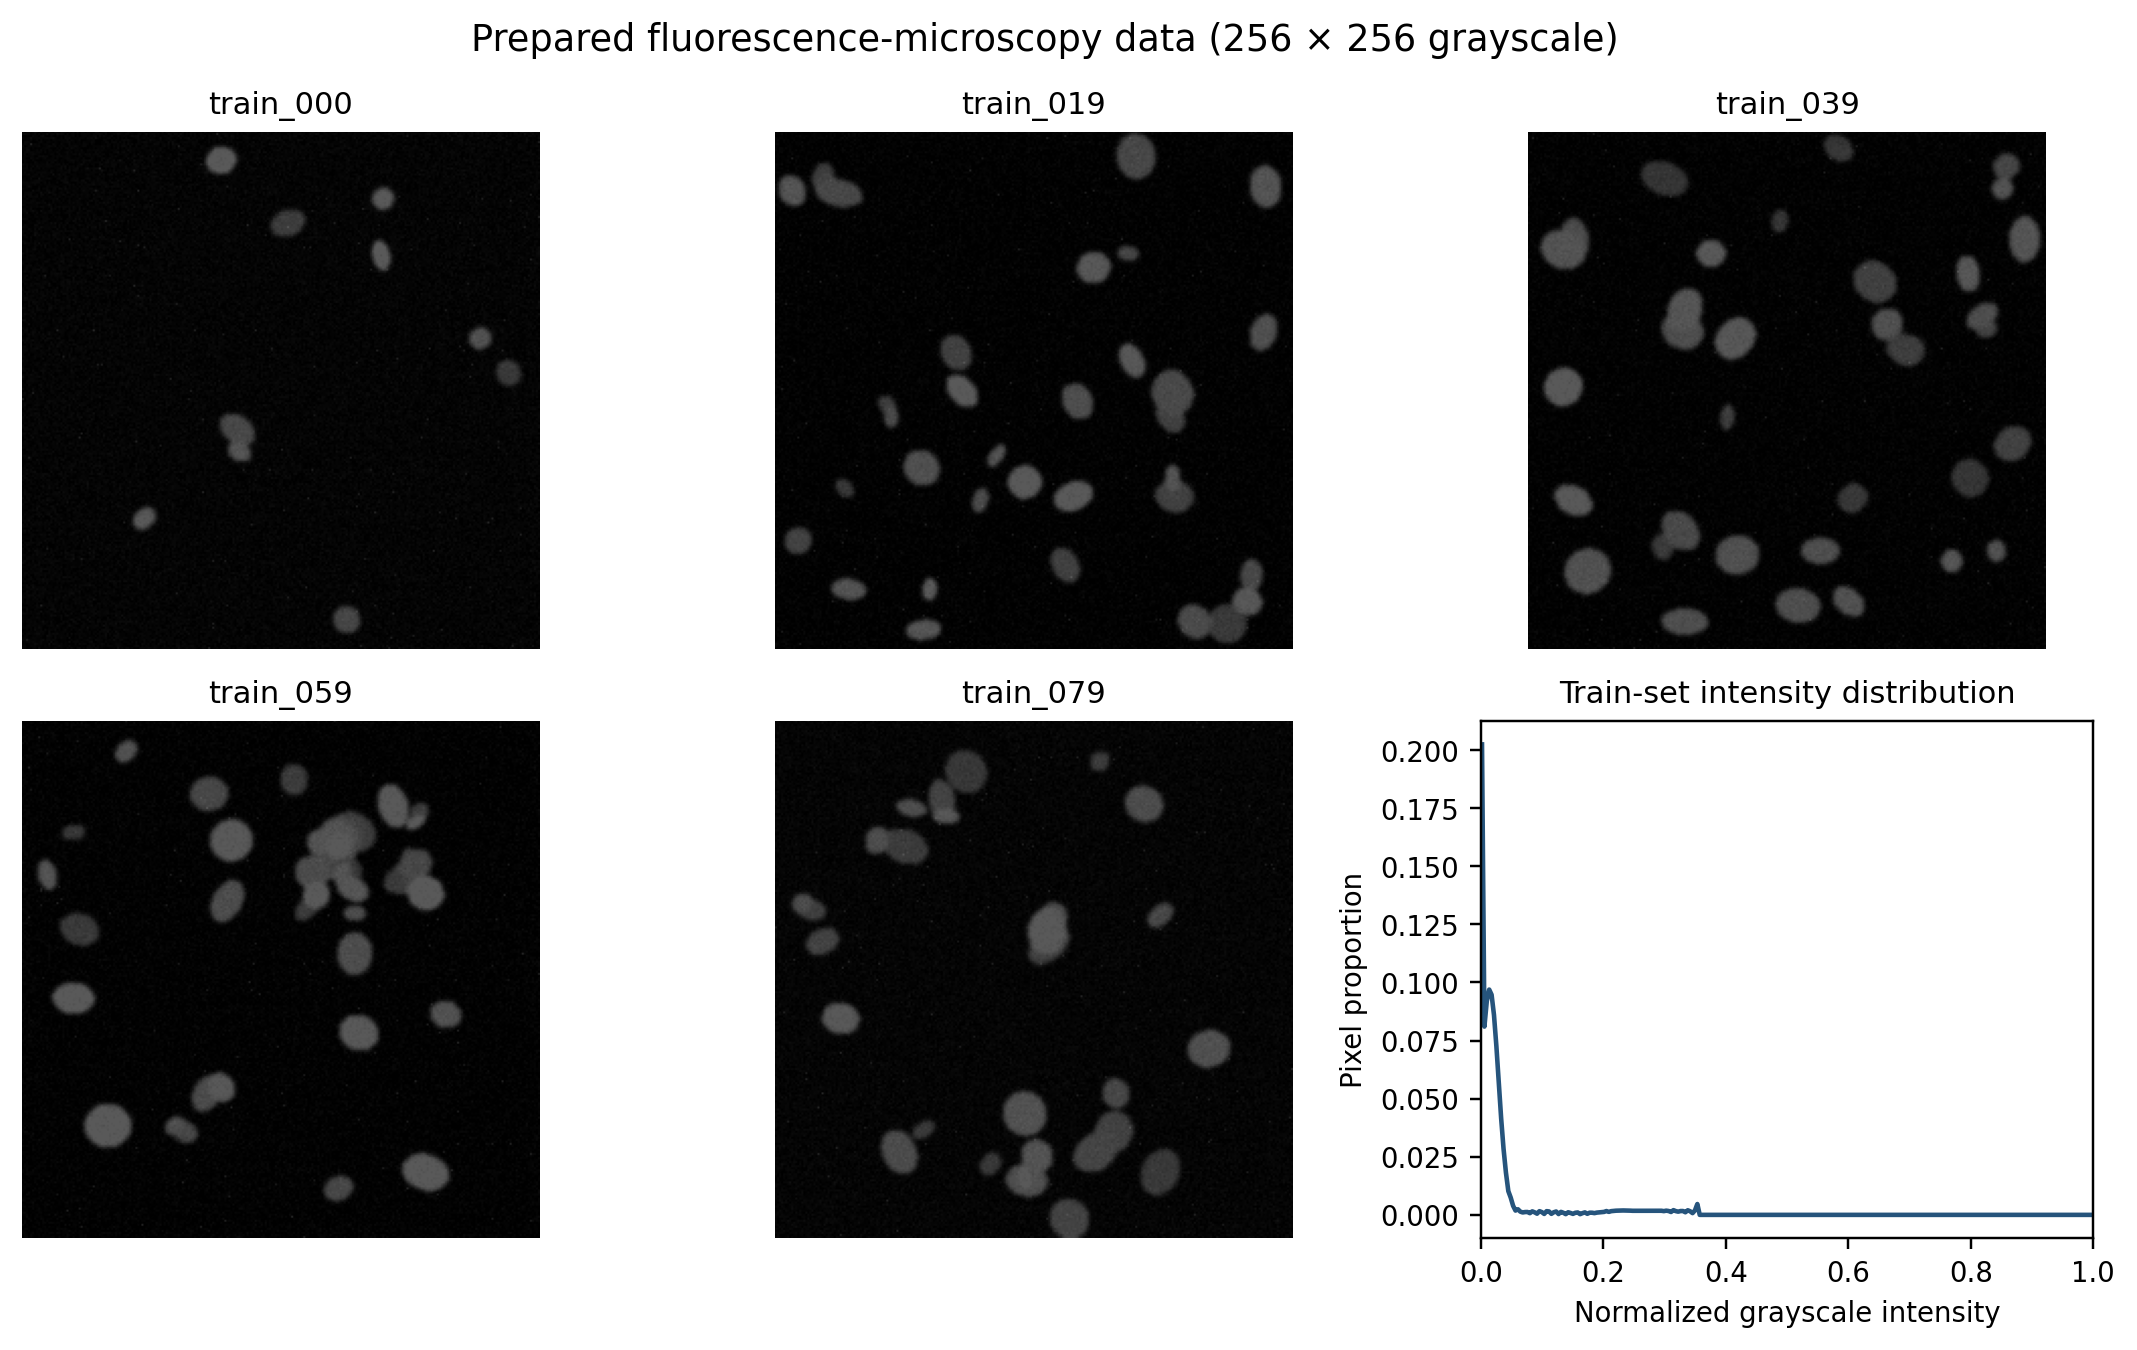

<IPython.core.display.JSON object>

In [10]:
from IPython.display import Image as NotebookImage
from IPython.display import JSON as NotebookJSON
from IPython.display import display

llm_client = OllamaClient() if RUN_LLM_STAGES else None
task1_preparation = run_preparation(DATA_DIR, OUTPUT_DIR)
display(NotebookJSON(data=task1_preparation))
display(NotebookImage(filename=str(OUTPUT_DIR / "task1" / "eda_overview.png")))

if RUN_LLM_STAGES:
    task1_vlm = run_task1_vlm(
        DATA_DIR, OUTPUT_DIR, llm_client, VISION_MODEL, repeats=VLM_REPEATS
    )
    display(NotebookJSON(data=task1_vlm))
else:
    print("Task 1 VLM skipped by configuration.")


## Task 2 — Classical segmentation and numbers-first description

Task 2 replaces visual guessing with an auditable measurement first route. Otsu
thresholding separates foreground nuclei from the background, morphological cleanup
removes small artifacts, and connected components provide a per object feature table
using region properties. The saved table and segmentation figure make both the mask
and its derived measurements available for inspection.

A text only local model receives a concise numerical summary and never sees the
image. Its JSON response must preserve the supplied object count and calculated
categories, allowing the result to be checked automatically. This creates a direct
comparison with Task 1: the vision model may offer richer visual language, whereas
the numbers-first account has a clearer evidential link to reproducible features.


<IPython.core.display.JSON object>

,label,area,perimeter,eccentricity,solidity,major_axis_length,minor_axis_length,mean_intensity,circularity
0,1,292.0,63.455844,0.784553,0.966887,24.498717,15.190723,0.301276,0.911275
1,2,179.0,47.798990,0.745863,0.988950,18.500387,12.323091,0.259809,0.984522
2,3,207.0,52.284271,0.702920,0.958333,19.253352,13.694319,0.207578,0.951564
3,4,294.0,62.284271,0.633049,0.963934,21.991384,17.023788,0.291890,0.952358
4,5,127.0,39.798990,0.765259,0.984496,15.826425,10.187835,0.233627,1.007557
5,6,53.0,26.142136,0.789019,0.929825,10.489047,6.444149,0.206585,0.974549
6,7,683.0,128.225397,0.858942,0.772624,47.011149,24.073135,0.275193,0.522014
7,8,151.0,42.627417,0.492732,0.974194,14.857777,12.928955,0.255162,1.044260
8,9,208.0,51.798990,0.690927,0.971963,19.145819,13.840988,0.291931,0.974161
9,10,161.0,43.798990,0.552000,0.987730,15.661022,13.058853,0.240507,1.054648


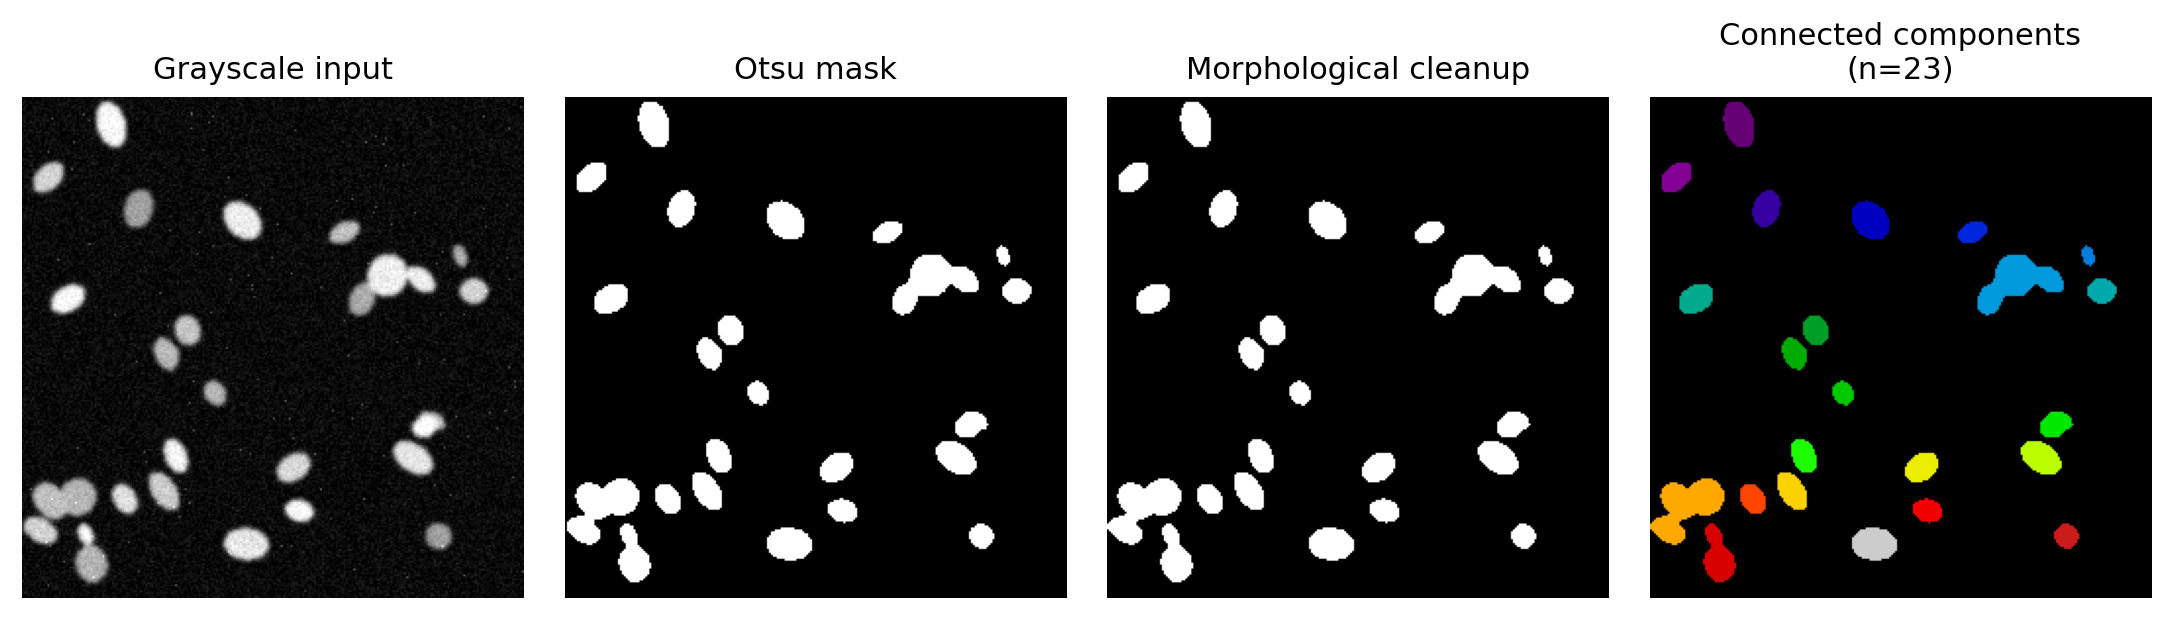

In [11]:
task2_result = run_task2_classical(
    DATA_DIR, OUTPUT_DIR, llm_client, TEXT_MODEL
)
display(NotebookJSON(data=task2_result))
representative_id = task1_preparation["representative_image_id"]
display(pd.read_csv(
    OUTPUT_DIR / "task2" / f"{representative_id}_regionprops.csv"
).head(10))
display(NotebookImage(filename=str(
    OUTPUT_DIR / "task2" / "classical_segmentation.png"
)))


## Task 3 — U-Net segmentation and controlled loss comparison

Task 3 evaluates whether a learned segmentation model can improve on the classical
baseline. Three compact U-Nets are trained with BCE, Dice, and combined BCE–Dice
loss. They share the same architecture, random seed, data split, optimiser, and
training budget, so differences in performance can be interpreted primarily as an
effect of the loss formulation rather than a change in experimental conditions.

Checkpoints are selected using validation Dice, and the chosen probability threshold
is also calibrated on validation data. Mean Dice and IoU quantify mask overlap, while
side-by-side prediction panels reveal where aggregate scores conceal boundary,
missed-object, or merged-object errors. The selected U-Net and Otsu baseline are
compared on the same validation images; test masks play no role in model selection.


[bce     ] epoch 01/10: train=0.5346, val=0.5902, Dice=0.0000, IoU=0.0000
[bce     ] epoch 02/10: train=0.4572, val=0.5323, Dice=0.3397, IoU=0.2086
[bce     ] epoch 03/10: train=0.4187, val=0.3986, Dice=0.9456, IoU=0.8969
[bce     ] epoch 04/10: train=0.3846, val=0.3653, Dice=0.9118, IoU=0.8380
[bce     ] epoch 05/10: train=0.3619, val=0.3561, Dice=0.8734, IoU=0.7755
[bce     ] epoch 06/10: train=0.3411, val=0.3336, Dice=0.9334, IoU=0.8753
[bce     ] epoch 07/10: train=0.3205, val=0.3143, Dice=0.9339, IoU=0.8762
[bce     ] epoch 08/10: train=0.3009, val=0.2918, Dice=0.9870, IoU=0.9743
[bce     ] epoch 09/10: train=0.2823, val=0.2737, Dice=0.9861, IoU=0.9726
[bce     ] epoch 10/10: train=0.2652, val=0.2539, Dice=0.9911, IoU=0.9824
[dice    ] epoch 01/10: train=0.7567, val=0.8726, Dice=0.0000, IoU=0.0000
[dice    ] epoch 02/10: train=0.7199, val=0.8607, Dice=0.5054, IoU=0.3434
[dice    ] epoch 03/10: train=0.7041, val=0.8355, Dice=0.8851, IoU=0.7949
[dice    ] epoch 04/10: train=0.6902, 

<IPython.core.display.JSON object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:718: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


,method,loss,mean_dice,mean_iou,std_dice,std_iou,epochs,seed,threshold
0,Otsu + morphology,not applicable,0.969672,0.941151,0.003411,0.006432,0,42,NaN
1,U-Net (combined),combined,0.994507,0.989078,0.001607,0.003176,10,42,0.70
2,U-Net (bce),bce,0.993646,0.987381,0.002133,0.004209,10,42,0.60
3,U-Net (dice),dice,0.991278,0.982716,0.002294,0.004504,10,42,0.65


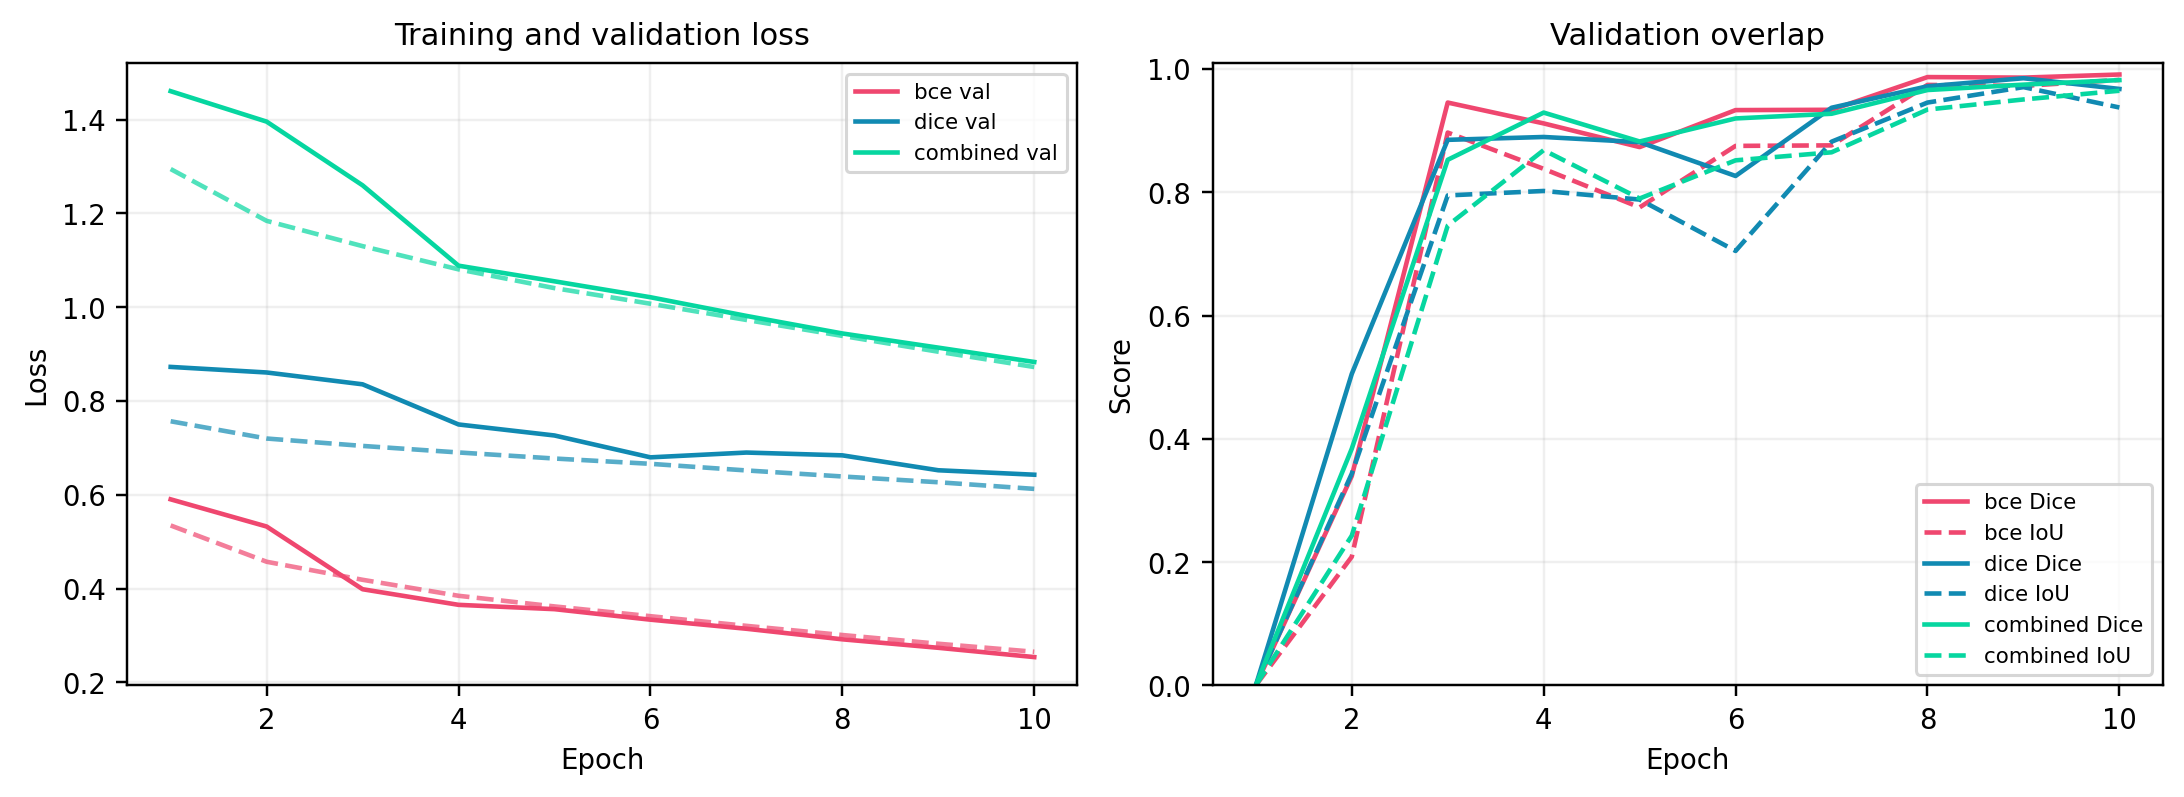

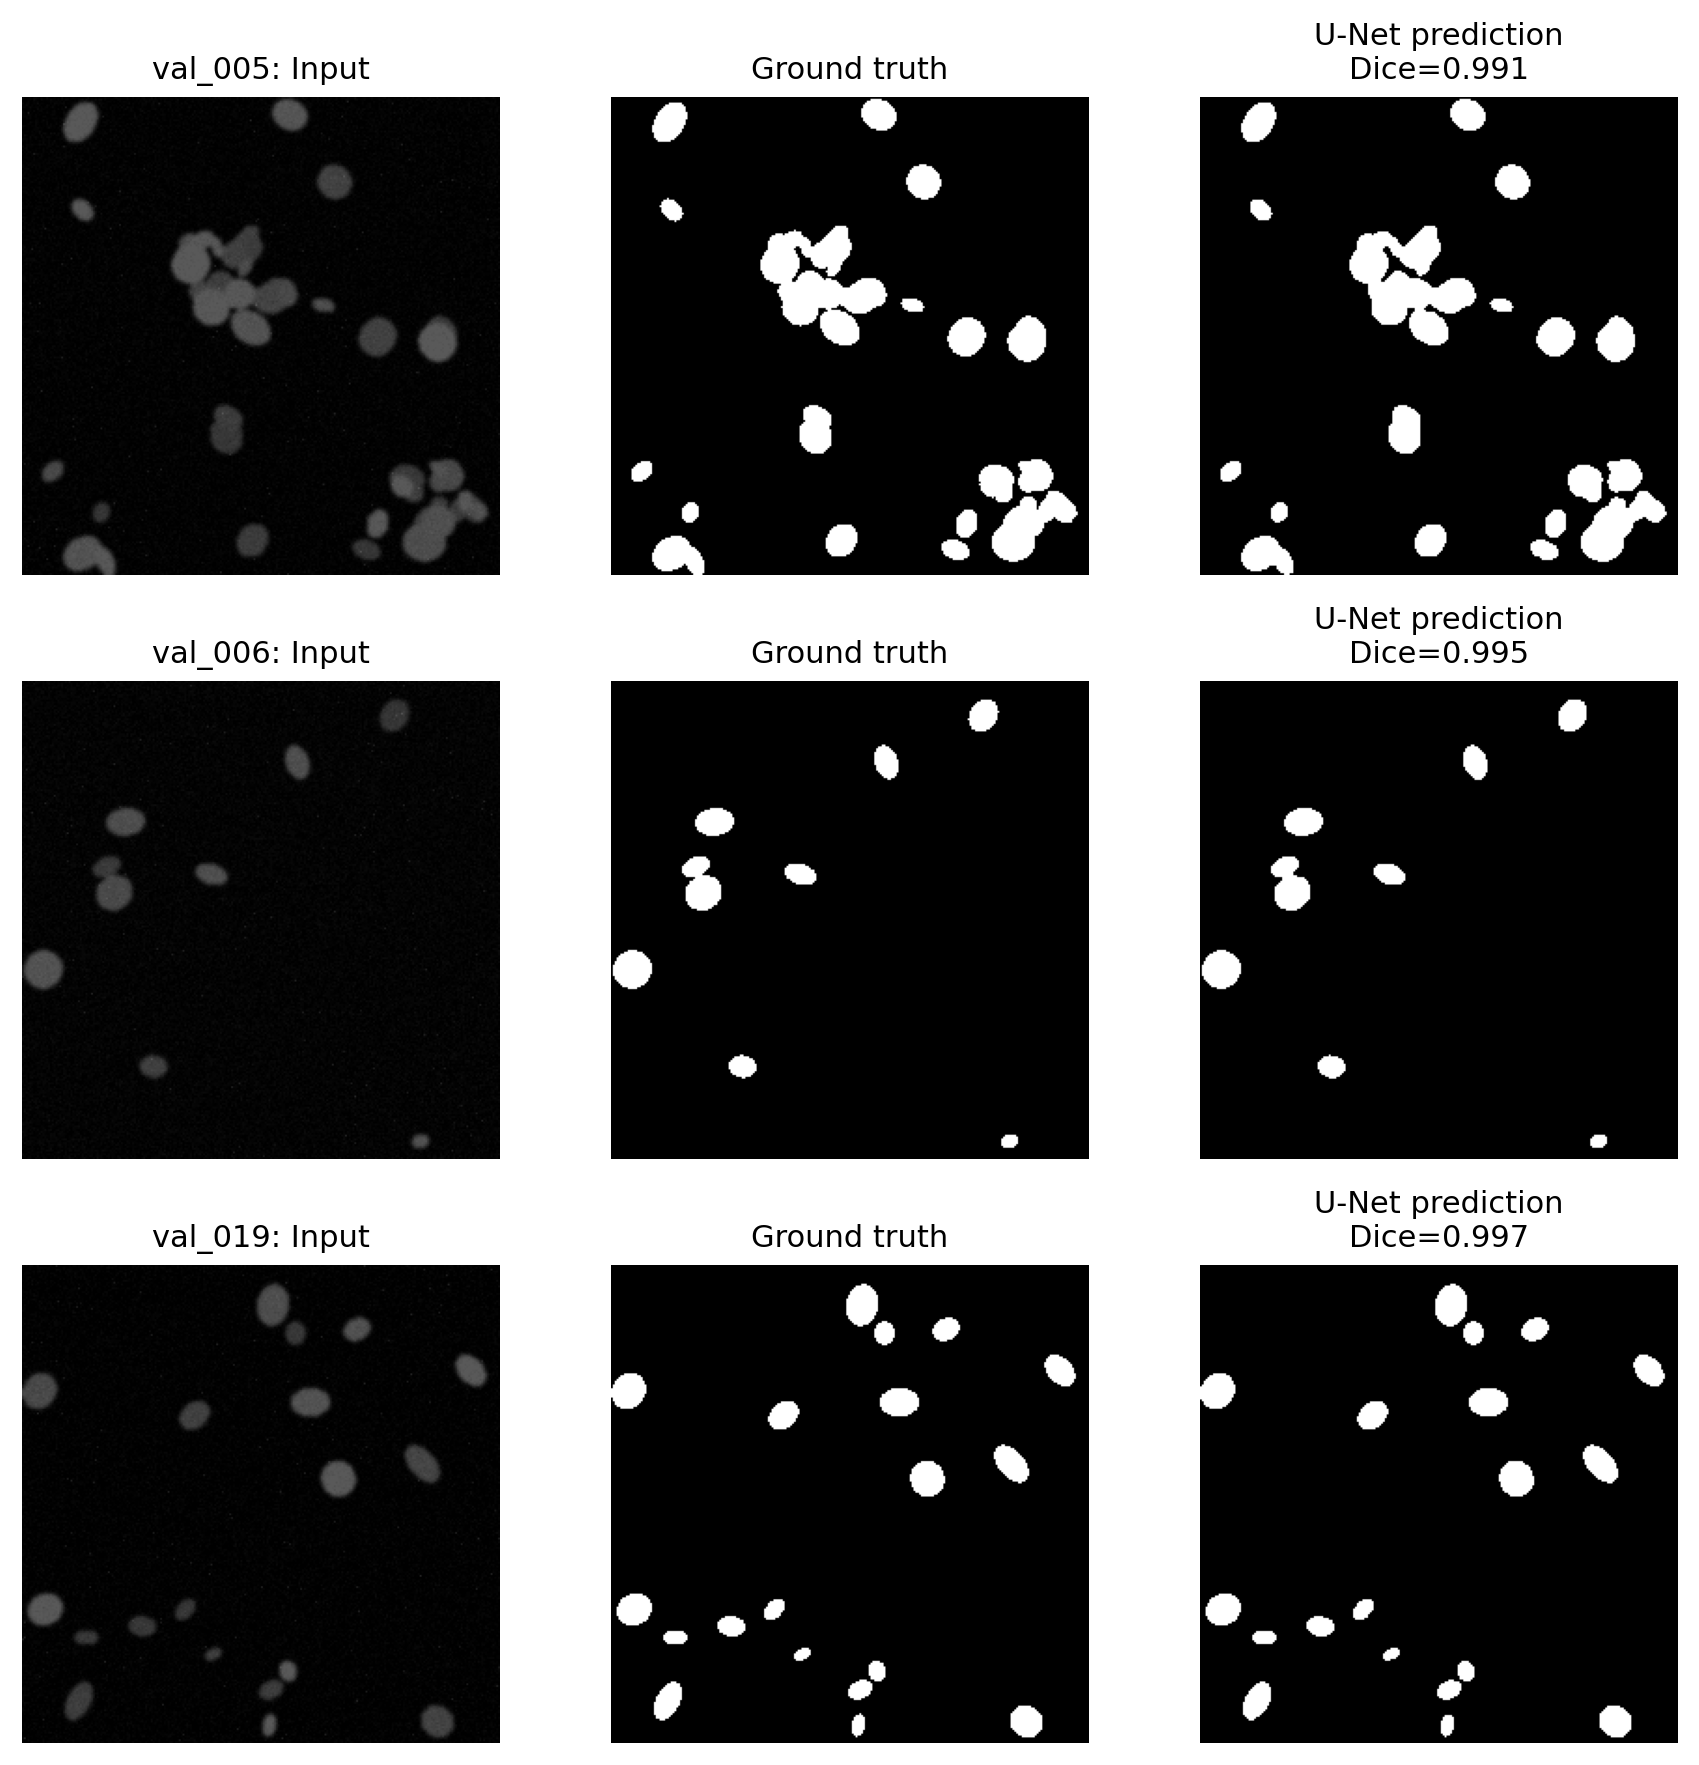

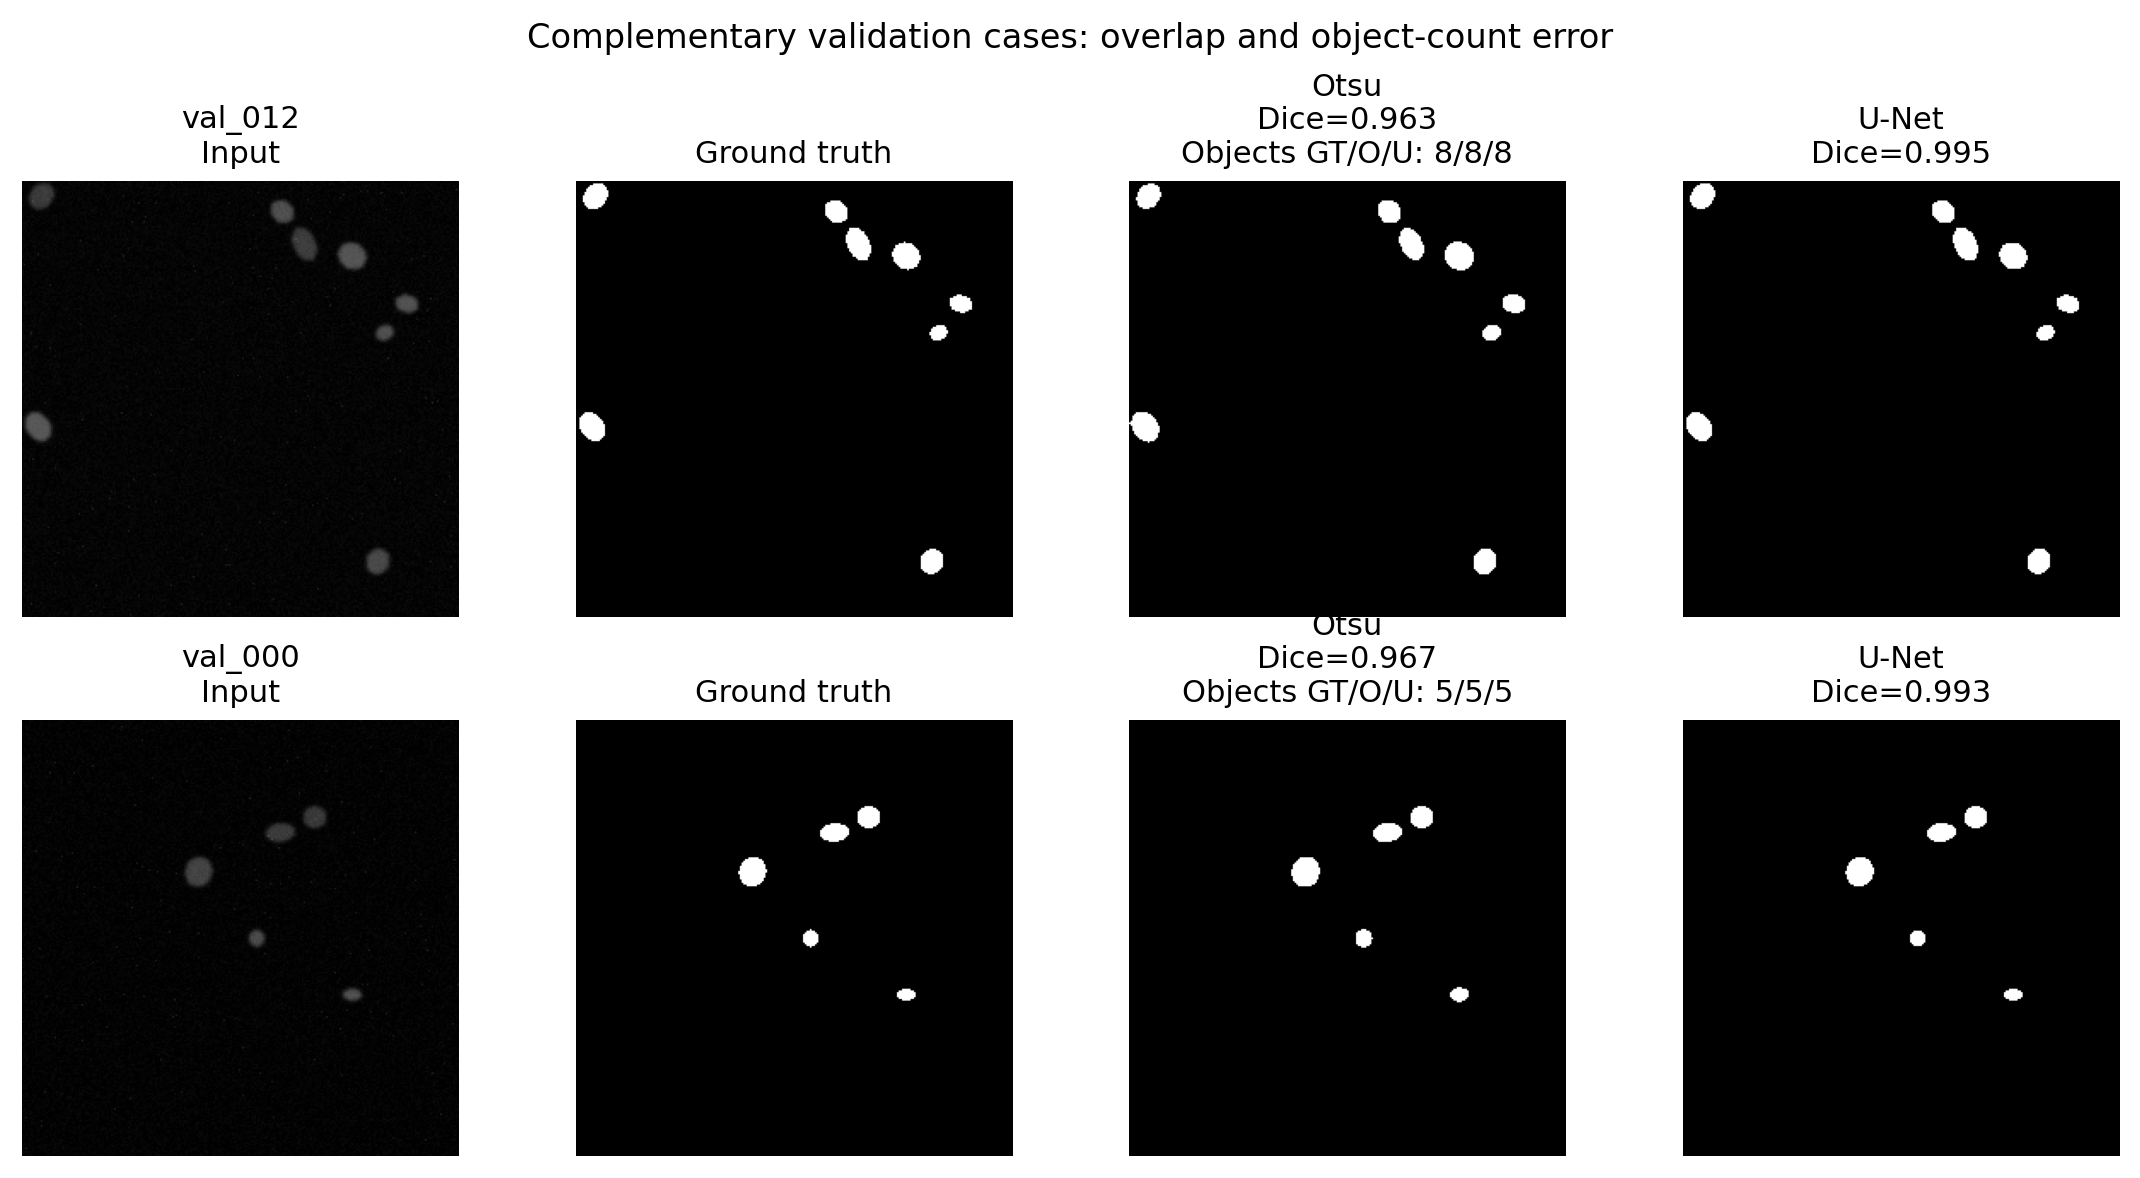

In [12]:
training_summary = run_training(
    DATA_DIR, OUTPUT_DIR, LOSS_NAMES, EPOCHS, BATCH_SIZE,
    LEARNING_RATE, BASE_CHANNELS, SEED, DEVICE
)
display(NotebookJSON(data=training_summary))
display(pd.read_csv(OUTPUT_DIR / "task3" / "evaluation_metrics.csv"))
for figure_name in [
    "loss_and_overlap_curves.png",
    "validation_predictions.png",
    "otsu_vs_unet_examples.png",
]:
    display(NotebookImage(filename=str(OUTPUT_DIR / "task3" / figure_name)))


## Task 4 — Hybrid analysis of unseen test images

Task 4 combines the strongest reusable components into the required end-to-end
workflow for unseen images. Each test image follows the same sequence: selected
U-Net mask → connected components → quantitative region features → validated JSON
record → short narrative. Applying one fixed workflow to every image supports a fair
aggregate analysis and avoids selecting methods after viewing individual results.

The structured record stores the image identifier, object count, mean area, density
class, and quality flag before the narrative is generated. These records are combined
into a DataFrame and exported as CSV. The narrative is therefore a human-readable
presentation of an existing record, not an input to later calculations.


In [13]:
best_checkpoint = Path(training_summary["best_checkpoint"])
test_records = run_hybrid_pipeline(
    DATA_DIR, OUTPUT_DIR, best_checkpoint, llm_client, TEXT_MODEL, DEVICE
)
display(test_records)
test_metrics = pd.read_csv(OUTPUT_DIR / "task4" / "held_out_test_metrics.csv")
display(test_metrics.describe())
print("Aggregate CSV:", OUTPUT_DIR / "task4" / "test_image_records.csv")


/tmp/ipykernel_3249/1932321905.py:86: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((np.asarray(mask, dtype=bool) * 255).astype(np.uint8), mode="L").save(path)
/tmp/ipykernel_3249/1932321905.py:86: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((np.asarray(mask, dtype=bool) * 255).astype(np.uint8), mode="L").save(path)
/tmp/ipykernel_3249/1932321905.py:86: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((np.asarray(mask, dtype=bool) * 255).astype(np.uint8), mode="L").save(path)
/tmp/ipykernel_3249/1932321905.py:86: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray((np.asarray(mask, dtype=bool) * 255).astype(np.uint8), mode="L").save(path)
/tmp/ipykernel_3249/1932321905.py:86: DeprecationWarning: 'mode' parameter is deprec

,image_id,n_objects,mean_area,density_class,quality_flag,narrative,llm_valid,validation_errors,model_checkpoint_loss
0,test_000,8,191.750000,sparse,ok,The image has been segmented and measured with...,True,,combined
1,test_001,14,200.642857,sparse,ok,The image has been segmented and measured with...,True,,combined
2,test_002,26,219.769231,moderate,ok,The image has been segmented and measured with...,True,,combined
3,test_003,19,204.421053,moderate,ok,The image has been segmented and measured with...,True,,combined
4,test_004,42,336.071429,dense,ok,The image has been segmented and measured with...,True,,combined
5,test_005,16,404.875000,moderate,ok,The image has been segmented and measured with...,True,,combined
6,test_006,8,198.625000,sparse,ok,The image has been segmented and measured with...,True,,combined
7,test_007,23,205.478261,moderate,ok,The image has been segmented and measured with...,True,,combined
8,test_008,23,239.782609,moderate,ok,The image has been segmented and measured with...,True,,combined
9,test_009,21,179.238095,moderate,ok,The image has been segmented and measured with...,True,,combined


,dice,iou
count,12.000000,12.000000
mean,0.994299,0.988666
std,0.001226,0.002425
min,0.992522,0.985155
25%,0.993228,0.986547
50%,0.994339,0.988742
75%,0.995072,0.990192
max,0.996195,0.992419


Aggregate CSV: /content/outputs/task4/test_image_records.csv


## Correction and Corruption Propagation

This additional robustness analysis examines how image degradation affects the full
pipeline rather than judging performance only on clean examples. Supplied blurred
and low contrast variants are compared with their clean reference as they pass
through input-quality checks, U-Net segmentation, region measurements, structured
records, and the final narrative. Changes in mask Dice and object count show whether
a visually modest corruption becomes a meaningful downstream measurement error.

The analysis records the earliest stage at which each corruption becomes detectable
and identifies the appropriate corrective response: retain the quality warning,
review the affected mask and measurements, and avoid presenting an unreliable
narrative as confident evidence. Here, correction refers to this quality control
action and audit trail; the image itself is not silently restored or replaced.


In [14]:
if RUN_ROBUSTNESS_EXTENSION:
    robustness_results = run_robustness_extension(
        DATA_DIR, OUTPUT_DIR, best_checkpoint, llm_client, TEXT_MODEL, DEVICE
    )
    display(robustness_results)
else:
    print("Robustness trace skipped in smoke-test mode.")


,corruption_id,base_image_id,earliest_detectable_stage,original_contrast,corrupted_contrast,original_focus,corrupted_focus,original_dice,corrupted_dice,original_n_objects,corrupted_n_objects,corrupted_quality_flag,narrative,llm_valid
0,test_000_blur,test_000,input quality gate,0.231373,0.117647,0.002978,0.000007,0.996089,0.742248,8,7,fail,The image has a low foreground fraction and hi...,True
1,test_000_lowcontrast,test_000,input quality gate,0.231373,0.035294,0.002978,0.000084,0.996089,0.045743,8,1,fail,The image has a single object with a mean area...,True
2,test_004_blur,test_004,input quality gate,0.352941,0.247059,0.003205,0.000028,0.993214,0.711091,42,14,review_recommended,"The image has been segmented and measured, wit...",True
3,test_004_lowcontrast,test_004,input quality gate,0.352941,0.050980,0.003205,0.000083,0.993214,0.355742,42,1,fail,The image has a single object with a mean area...,True


## Evidence validation and export

Reproducibility requires more than a successful final display, so this section checks
that the essential marking evidence has actually been written to disk. The required
artifacts cover prompts, exploratory analysis, structured language-model outputs,
evaluation metrics, training figures, validation predictions, and aggregate test
records. A missing item raises a visible error rather than creating an incomplete
archive without warning.

Once the check passes, all outputs are packaged into one downloadable ZIP file. Any
numerical result quoted in the report should be taken directly from these saved CSV,
JSON, or figure sources instead of being copied from memory.


In [15]:
evidence = [
    OUTPUT_DIR / "prompts.txt",
    OUTPUT_DIR / "task1" / "eda_overview.png",
    OUTPUT_DIR / "task1" / "vlm_prompt_comparison.json",
    OUTPUT_DIR / "task2" / "numbers_first_llm_output.json",
    OUTPUT_DIR / "task3" / "evaluation_metrics.csv",
    OUTPUT_DIR / "task3" / "loss_and_overlap_curves.png",
    OUTPUT_DIR / "task3" / "validation_predictions.png",
    OUTPUT_DIR / "task4" / "test_image_records.csv",
    OUTPUT_DIR / "task4" / "held_out_test_metrics.csv",
]
evidence_check = pd.DataFrame({
    "artifact": [str(path.relative_to(OUTPUT_DIR)) for path in evidence],
    "exists": [path.exists() for path in evidence],
})
display(evidence_check)
if not evidence_check["exists"].all():
    missing = evidence_check.loc[~evidence_check["exists"], "artifact"].tolist()
    raise FileNotFoundError(f"Missing required evidence: {missing}")

archive_path = shutil.make_archive(
    str(ROOT_DIR / "final_outputs"), "zip", root_dir=OUTPUT_DIR
)
print(f"Complete output archive: {archive_path}")
print("Download it from the Colab Files panel.")


,artifact,exists
0,prompts.txt,True
1,task1/eda_overview.png,True
2,task1/vlm_prompt_comparison.json,True
3,task2/numbers_first_llm_output.json,True
4,task3/evaluation_metrics.csv,True
5,task3/loss_and_overlap_curves.png,True
6,task3/validation_predictions.png,True
7,task4/test_image_records.csv,True
8,task4/held_out_test_metrics.csv,True


Complete output archive: /content/final_outputs.zip
Download it from the Colab Files panel.
